# Cobertura de Vale-Refeição no iFood: um retrato da desigualdade em São Paulo

> **Resumo executivo**
>
> Este estudo mapeou a aceitação de bandeiras de vale-refeição (VR) em **800 restaurantes de 40
> distritos** de São Paulo, cruzando dados coletados do iFood com indicadores socioeconômicos do
> Mapa da Desigualdade 2025.
>
> **Principal achado:** praticamente todos os restaurantes aceitam *algum* VR (98,4%), mas a
> aceitação de bandeiras *específicas* é fortemente desigual e acompanha a renda do distrito.
> Nos distritos de alta renda, os restaurantes aceitam em média 64% de cobertura de Alelo; nos de
> baixa renda, apenas 37%. A correlação entre renda e cobertura é positiva e estatisticamente
> significativa para todas as quatro grandes operadoras privadas.
>
> **Conclusão:** o trabalhador de menor renda, que mais depende do benefício, é justamente quem tem
> menos chance de encontrar a sua bandeira. O problema não está em "aceitar VR", mas em "aceitar a
> bandeira certa", e isso reproduz o mapa da desigualdade da cidade.
>
> *Stack: Python (pandas, scikit-learn, XGBoost, SHAP), análise estatística (Pearson, qui-quadrado),
> Folium. Metodologia CRISP-DM.*

---

In [3]:
# ============================================================
# IMPORTS E CONFIGURACAO
# ============================================================
# Manipulacao de dados
import pandas as pd
import numpy as np
import json
import os
import warnings
from collections import Counter

# Visualizacao
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Estatistica
from scipy import stats

# Machine learning
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
import shap

# Mapa interativo
import folium
from branca.colormap import LinearColormap

warnings.filterwarnings("ignore")
os.makedirs("images", exist_ok=True)

# Define o diretorio raiz do projeto.
# AJUSTE este caminho para a pasta do projeto na sua maquina (ver README).
os.chdir(r"C:\\Users\\xuao\\PycharmProjects\\IfoodProject")

pd.options.display.float_format = "{:,.2f}".format

# ============================================================
# PALETA DE CORES DO PROJETO
# ============================================================
AMARELO   = "#F2C230"   # destaque / categorias claras
LARANJA_M = "#F2921D"   # cor primaria
LARANJA_I = "#F24F13"   # enfase / valores altos
AZUL      = "#8082A6"   # neutro / comparacao
ROXO      = "#46334F"   # texto forte / categorias escuras

COR_PRIMARIA = LARANJA_M
PALETTE = [LARANJA_M, ROXO, AMARELO, AZUL, LARANJA_I]
PALETTE_Q = [LARANJA_I, LARANJA_M, AMARELO, AZUL]
CORES_PERFIL = {"alto":AZUL, "medio_alto":AMARELO, "medio":LARANJA_M, "popular":LARANJA_I}
CMAP = LinearSegmentedColormap.from_list("projeto", [ROXO, LARANJA_I, LARANJA_M, AMARELO])

# Gera N cores distintas interpolando a paleta (graficos com muitas categorias)
def cores_n(n):
    cmap_cat = LinearSegmentedColormap.from_list("cat", [ROXO, AZUL, LARANJA_I, LARANJA_M, AMARELO])
    return [cmap_cat(i/(max(n-1,1))) for i in range(n)]

plt.rcParams.update({
    "figure.dpi": 130, "font.family": "sans-serif",
    "axes.spines.top": False, "axes.spines.right": False,
})
print("Imports OK | paleta carregada")

Imports OK | paleta carregada


---
## 1. Entendimento do Negócio

O Programa de Alimentação do Trabalhador (PAT) alcança **22,1 milhões de trabalhadores formais**
no Brasil, distribuídos em 327.736 empresas (Ministério do Trabalho e Emprego, 2025). O benefício
é pago por operadoras como Alelo, Sodexo/Pluxee, VR Benefícios, Ticket/Edenred e outras.

Em novembro de 2025 foi publicado decreto que torna obrigatória a **interoperabilidade plena
do PAT em 360 dias**: qualquer cartão deverá ser aceito em qualquer estabelecimento, independente
da operadora. Este projeto mapeia a cobertura atual de VR no iFood **antes dessa mudança**,
constituindo uma linha de base.

### Pergunta de pesquisa

> A aceitação de bandeiras de vale-refeição nos restaurantes do iFood está associada
> ao perfil socioeconômico do distrito?

### Hipóteses

- **H1:** Distritos de maior renda têm maior cobertura de bandeiras de VR.
- **H2:** A cobertura de "qualquer VR" é alta e homogênea, mas a de bandeiras específicas é desigual.
- **H3:** O número médio de bandeiras aceitas por restaurante cai com a renda do distrito.

---
## 2. Entendimento e Preparação dos Dados

### 2.1 Metodologia de coleta

Os dados de restaurantes foram coletados manualmente da API interna do iFood
(`HOME_FOOD_DELIVERY_V3`) entre 15 e 16 de junho de 2026, capturando os 20 primeiros
restaurantes listados para um endereço residencial de cada distrito. Para cada restaurante,
consultou-se o endpoint de métodos de pagamento para identificar as bandeiras de VR aceitas.

**Amostragem estratificada:** 40 distritos selecionados a partir do ranking de Trabalho e Renda
do Mapa da Desigualdade 2025 (Rede Nossa São Paulo), distribuídos em 4 quartis de 10 distritos cada.
Os endereços de busca foram escolhidos em vias residenciais, reproduzindo o cenário de uso real
de um trabalhador acessando o app de casa.

**Tratamento de sobreposição:** distritos vizinhos podem compartilhar restaurantes (mesmo raio de
entrega). Optou-se por manter o restaurante em cada distrito de onde é acessível, pois a unidade
de análise é "oferta acessível ao morador do distrito", não "restaurante único na cidade".

### 2.2 Fontes externas

| Fonte                                     | Uso |
|-------------------------------------------|---|
| Mapa da Desigualdade 2025 (Rede Nossa SP) | Renda, oferta de emprego e desigualdade salarial por distrito |
| Ministério do Trabalho (PAT)              | Contexto: nº de beneficiários e decreto de interoperabilidade |
| ABBT (Pesquisa Preço Médio)               | Preço médio de refeição comercial em SP (R\\$ 44,16, set/2025) |

### 2.3 Carga e cruzamento das bases

In [4]:
# Base do iFood (800 restaurantes, 40 distritos)
df = pd.read_csv("data/processed/restaurantes_20260617_1916.csv")

# Base socioeconomica (Mapa da Desigualdade 2025)
socio = pd.read_csv("data/processed/dados_socioeconomicos_40_distritos.csv")

# Cruzamento
df = df.merge(socio, on="bairro_busca", how="left")

print(f"Restaurantes: {len(df)}  |  Distritos: {df['bairro_busca'].nunique()}")
print(f"Distritos sem dado socioeconomico: {df['remuneracao_media'].isna().sum()}")
df.head(3)

Restaurantes: 800  |  Distritos: 40
Distritos sem dado socioeconomico: 0


,id,nome,categoria,nota,distancia_km,taxa_entrega_reais,tempo_min,tempo_max,is_super_restaurante,bairro_busca,...,aceita_qualquer_vr,bandeiras_vr_raw,qtd_bandeiras_vr,remuneracao_media,pos_remuneracao,oferta_emprego_formal,pos_oferta,desigualdade_salarial,pos_desigualdade,score_trabalho_renda
0,1710b8bb-7d5c-4c3d-8cc4-77231809a460,Padaria Santa Branca,Padaria,4.90,0.27,6.99,51.00,66.00,True,Agua Rasa,...,True,"[""ALELO"", ""IFOOD_MEAL_VOUCHER"", ""SODEXO"", ""TIC...",5,"3,085.67",46,4.25,37,1.12,9,30.67
1,321b6f24-3237-4dbc-9f5a-ce123a9355b0,Burger King - Ils Shop Metro Tatuape II,Lanches,4.80,1.25,6.99,36.00,51.00,False,Agua Rasa,...,True,"[""IFOOD_MEAL_VOUCHER"", ""TICKET""]",2,"3,085.67",46,4.25,37,1.12,9,30.67
2,05d770f3-048f-4e26-bc74-416e0e6631c6,Babbo Giovanni Pizza,Pizza,4.90,1.34,6.00,45.00,55.00,True,Agua Rasa,...,True,"[""ALELO"", ""BEN_MEAL_VOUCHER"", ""IFOOD_MEAL_VOUC...",7,"3,085.67",46,4.25,37,1.12,9,30.67


### 2.4 Feature engineering

In [5]:
# Variaveis derivadas
df["tempo_medio"] = (df["tempo_min"] + df["tempo_max"]) / 2
df["tem_entrega_gratis"] = (df["taxa_entrega_reais"] == 0).astype(int)

# Ordena perfil como categoria ordinal (popular -> alto)
ORDEM_PERFIL = ["popular", "medio", "medio_alto", "alto"]
LABEL_PERFIL = {"popular":"Q4 Popular","medio":"Q3 Médio",
                "medio_alto":"Q2 Médio-alto","alto":"Q1 Alto"}
df["perfil"] = pd.Categorical(df["perfil"], categories=ORDEM_PERFIL, ordered=True)
df["perfil_label"] = df["perfil"].map(LABEL_PERFIL)

# Bandeiras regionais (fora das grandes operadoras nacionais)
REGIONAIS = {"VEROCARD","GREENCARD","REFEISUL","VALE_CARD","NUTRICARD"}
df["lista_bandeiras"] = df["bandeiras_vr_raw"].apply(lambda r: json.loads(r) if isinstance(r,str) else [])
df["aceita_vr_regional"] = df["lista_bandeiras"].apply(lambda b: len(set(b) & REGIONAIS) > 0)

# Quantidade de bandeiras PRIVADAS (foco da analise de desigualdade)
df["qtd_privadas"] = df[["aceita_alelo","aceita_sodexo","aceita_vr","aceita_ticket"]].sum(axis=1)

# Categoria agrupada (top 8 + Outros)
top_cats = df["categoria"].value_counts().head(8).index
df["categoria_agrupada"] = df["categoria"].where(df["categoria"].isin(top_cats), "Outros")

print("Features criadas com sucesso.")
print(f"Restaurantes com bandeira regional: {df['aceita_vr_regional'].sum()} ({df['aceita_vr_regional'].mean()*100:.1f}%)")
print(f"Categorias apos agrupamento: {df['categoria_agrupada'].nunique()}")

Features criadas com sucesso.
Restaurantes com bandeira regional: 37 (4.6%)
Categorias apos agrupamento: 9


### 2.5 Dicionário das variáveis principais

| Variável | Descrição                                                                 |
|---|---------------------------------------------------------------------------|
| `bairro_busca` | Distrito oficial de São Paulo                                             |
| `perfil` | Quartil de renda (Q1 alto → Q4 popular)                                   |
| `remuneracao_media` | Remuneração média mensal do emprego formal (R\\$), Mapa Desigualdade 2025 |
| `oferta_emprego_formal` | Indicador de oferta de emprego formal no distrito                         |
| `desigualdade_salarial` | Índice de desigualdade salarial no emprego formal                         |
| `aceita_alelo` … `aceita_ben` | Aceitação de cada bandeira (booleano)                                     |
| `aceita_qualquer_vr` | Aceita ao menos uma bandeira de VR                                        |
| `qtd_bandeiras_vr` | Número de bandeiras de VR aceitas                                         |
| `aceita_vr_regional` | Aceita ao menos uma bandeira regional                                     |
| `nota`, `distancia_km`, `taxa_entrega_reais`, `tempo_medio` | Atributos do restaurante                                                  |
| `is_super_restaurante` | Selo Super Restaurante iFood                                              |

---
## Nota metodológica: por que o iFood Benefícios fica fora das comparações

Antes de iniciar a análise exploratória, é preciso justificar uma decisão importante. Entre as
bandeiras mapeadas, o **iFood Benefícios** (bandeira própria da plataforma) comporta-se de forma
radicalmente diferente das demais: está presente em praticamente todos os restaurantes,
independentemente do distrito ou do perfil de renda. O gráfico abaixo demonstra isso.

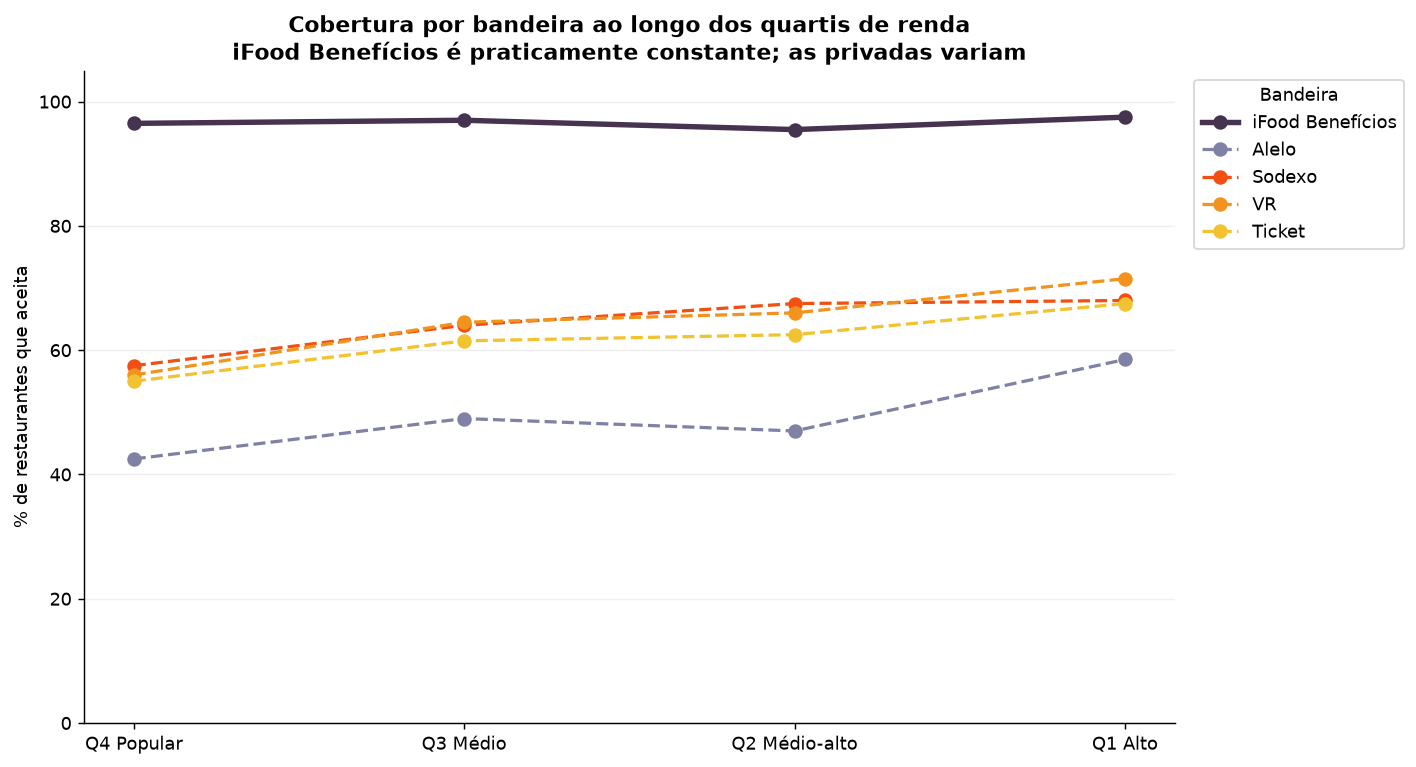

iFood Benefícios: varia apenas 0.9 pp entre quartis (96% a 98%)
Bandeiras privadas: variam de 8 a 11 pp entre quartis


In [6]:
ORDEM = ["popular","medio","medio_alto","alto"]
LABELS_Q = ["Q4 Popular","Q3 Médio","Q2 Médio-alto","Q1 Alto"]
df["perfil"] = pd.Categorical(df["perfil"], categories=ORDEM, ordered=True)

bandeiras_cmp = ["aceita_ifood_beneficios","aceita_alelo","aceita_sodexo","aceita_vr","aceita_ticket"]
nomes_cmp = ["iFood Benefícios","Alelo","Sodexo","VR","Ticket"]
cores_cmp = cores_n(len(nomes_cmp))

fig, ax = plt.subplots(figsize=(11, 6))
for col, nome, cor in zip(bandeiras_cmp, nomes_cmp, cores_cmp):
    vals = (df.groupby("perfil", observed=True)[col].mean()*100).reindex(ORDEM)
    estilo = "-o" if col=="aceita_ifood_beneficios" else "--o"
    lw = 3 if col=="aceita_ifood_beneficios" else 1.8
    ax.plot(LABELS_Q, vals.values, estilo, color=cor, label=nome, linewidth=lw, markersize=7)

ax.set_ylabel("% de restaurantes que aceita")
ax.set_xlabel("")
ax.set_title("Cobertura por bandeira ao longo dos quartis de renda\niFood Benefícios é praticamente constante; as privadas variam",
             fontweight="bold")
ax.legend(title="Bandeira", bbox_to_anchor=(1.01,1), loc="upper left")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("images/02_ifood_beneficios_universal.png", bbox_inches="tight", dpi=150)
plt.show()

desv_ifood = (df.groupby("perfil", observed=True)["aceita_ifood_beneficios"].mean()*100).std()
print(f"iFood Benefícios: varia apenas {desv_ifood:.1f} pp entre quartis (96% a 98%)")
print("Bandeiras privadas: variam de 8 a 11 pp entre quartis")

**Justificativa da exclusão:**

O iFood Benefícios varia menos de 1 ponto percentual entre os quartis de renda, contra 8 a 11
pontos das bandeiras privadas. Por ser quase universal e não discriminar entre regiões, **ele não
ajuda a responder a pergunta de pesquisa**, que é sobre desigualdade de acesso.

Por isso, a partir daqui as análises de desigualdade focam nas **bandeiras privadas** (Alelo,
Sodexo, VR Benefícios e Ticket), que são as que de fato variam entre distritos e onde o trabalhador
encontra ou não a sua bandeira. O iFood Benefícios permanece registrado no panorama geral (Seção 3),
mas sai das comparações por quartil, categoria e renda.

> **Nota:** nenhuma bandeira isolada é tomada como "a medida" do problema. As análises a seguir
> exibem as quatro bandeiras privadas **lado a lado**, permitindo ver que o padrão de desigualdade
> se repete em todas elas, não é um fenômeno exclusivo de uma operadora.

---
## 3. Análise Exploratória, Parte 1: Panorama de Cobertura

### 3.1 Quais bandeiras os restaurantes aceitam?

A primeira pergunta é descritiva: entre os 800 restaurantes coletados, qual a taxa de aceitação
de cada bandeira de VR? O resultado já revela a tese central do projeto.

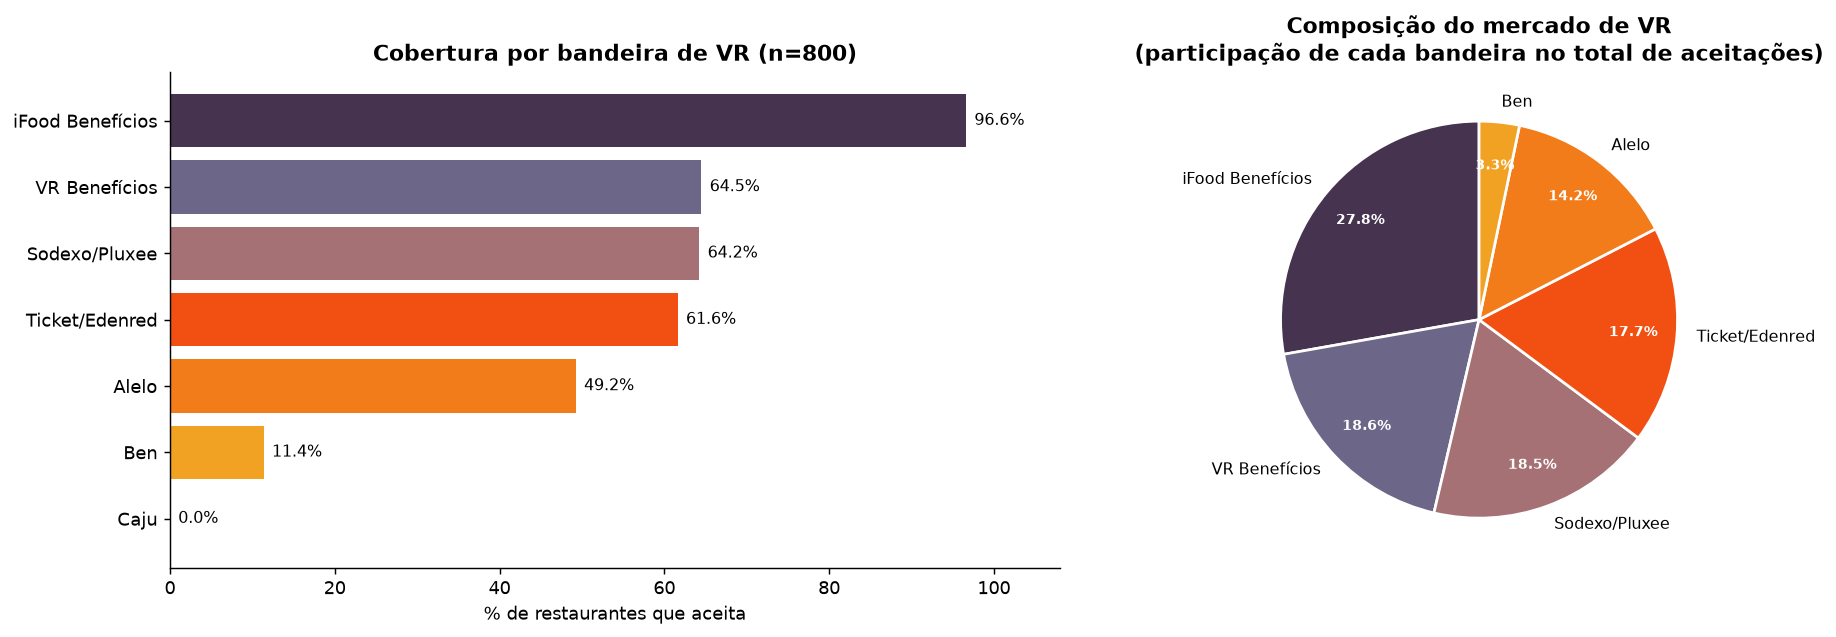

In [7]:
colunas_vr = ["aceita_ifood_beneficios","aceita_vr","aceita_sodexo","aceita_ticket",
              "aceita_alelo","aceita_ben","aceita_caju"]
nomes_vr = ["iFood Benefícios","VR Benefícios","Sodexo/Pluxee","Ticket/Edenred",
            "Alelo","Ben","Caju"]

cobertura = (df[colunas_vr].mean()*100)
cores_bandeiras = cores_n(len(nomes_vr))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Esquerda: % de restaurantes que aceita cada bandeira
bars = axes[0].barh(nomes_vr, cobertura.values, color=cores_bandeiras)
axes[0].invert_yaxis()
axes[0].set_xlabel("% de restaurantes que aceita")
axes[0].set_title("Cobertura por bandeira de VR (n=800)", fontweight="bold")
for bar, val in zip(bars, cobertura.values):
    axes[0].text(val+1, bar.get_y()+bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
axes[0].set_xlim(0, 108)

# Direita: market share (composicao do total de aceitacoes)
total_aceitacoes = df[colunas_vr].sum()
share = total_aceitacoes / total_aceitacoes.sum() * 100
# remove bandeiras com 0 para nao poluir
mask = share > 0
wedges, texts, autotexts = axes[1].pie(
    share[mask].values,
    labels=[n for n,m in zip(nomes_vr, mask) if m],
    colors=[c for c,m in zip(cores_bandeiras, mask) if m],
    autopct="%1.1f%%", startangle=90, pctdistance=0.78,
    wedgeprops={"edgecolor":"white","linewidth":1.5})
plt.setp(autotexts, size=8, weight="bold", color="white")
plt.setp(texts, size=9)
axes[1].set_title("Composição do mercado de VR\n(participação de cada bandeira no total de aceitações)",
                  fontweight="bold")

plt.tight_layout()
plt.savefig("images/03_cobertura_bandeiras.png", bbox_inches="tight", dpi=150)
plt.show()

**Leitura dos resultados:**

Dois fatos se destacam. Primeiro, há uma forte hierarquia entre bandeiras: o **iFood Benefícios**
(bandeira própria da plataforma) lidera com 97% de presença, enquanto o **Alelo**, maior operadora
privada do país, aparece em menos da metade dos restaurantes (48%). O Caju não foi aceito por
nenhum restaurante da amostra, e o Ben por apenas 9,6%.

O gráfico de composição à direita reforça o ponto: das 2.721 aceitações de VR somadas na amostra,
o iFood Benefícios sozinho responde por 28,5%. As quatro grandes operadoras privadas (VR, Sodexo,
Ticket e Alelo) se dividem de forma relativamente equilibrada o restante.

Como 98,4% dos restaurantes aceitam ao menos uma bandeira, fica claro que **o gap de cobertura
não está em "ter VR", mas em "ter a bandeira específica que o trabalhador possui"**, o que
sustenta a Hipótese 2 e orienta o restante da análise.

### 3.2 Quantas bandeiras cada restaurante aceita?

Se um restaurante aceita muitas bandeiras, o trabalhador tem mais chance de encontrar a sua.
A distribuição da quantidade de bandeiras por restaurante mostra como essa "variedade" se espalha.

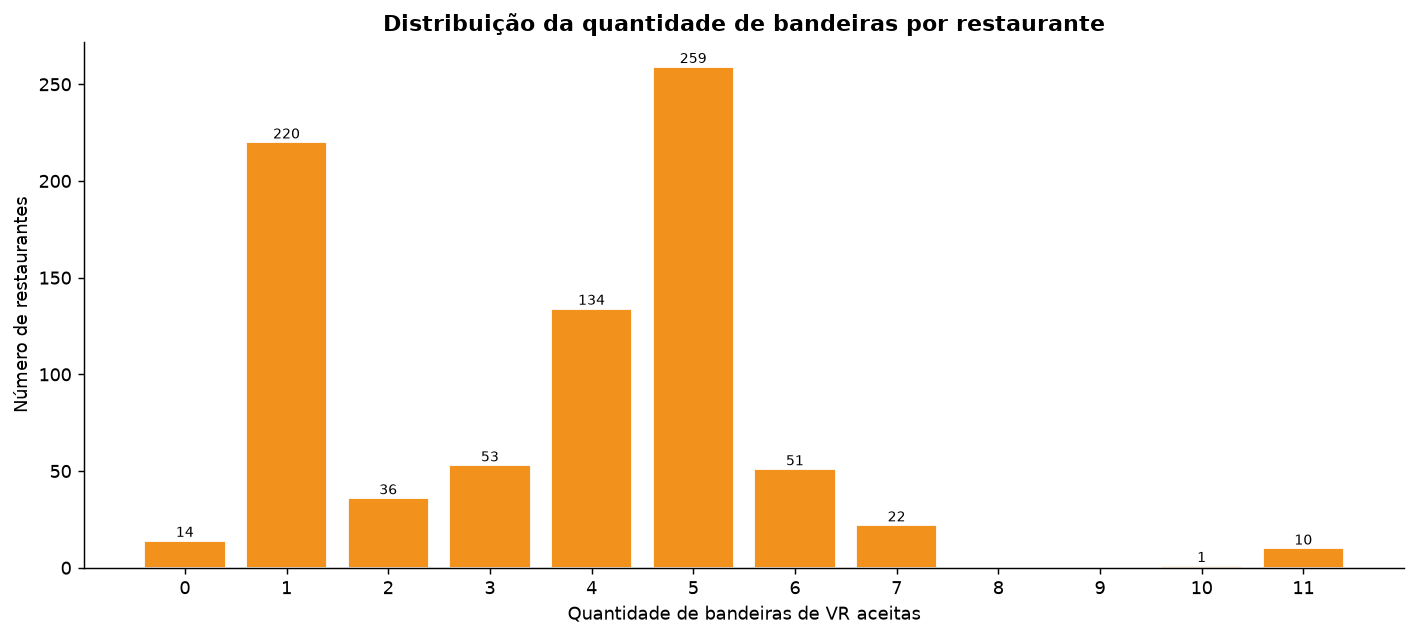

Média: 3.58 bandeiras
Mediana: 4 bandeiras
Restaurantes que aceitam 5+ bandeiras: 343 (42.9%)
Restaurantes que aceitam apenas 1 bandeira: 220 (27.5%)


In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
dist = df["qtd_bandeiras_vr"].value_counts().sort_index()
bars = ax.bar(dist.index, dist.values, color=COR_PRIMARIA, edgecolor="white")
ax.set_xlabel("Quantidade de bandeiras de VR aceitas")
ax.set_ylabel("Número de restaurantes")
ax.set_title("Distribuição da quantidade de bandeiras por restaurante", fontweight="bold")
for bar, val in zip(bars, dist.values):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, val+2, str(val), ha="center", fontsize=8)
ax.set_xticks(range(0, int(dist.index.max())+1))
plt.tight_layout()
plt.savefig("images/03_qtd_bandeiras.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Média: {df['qtd_bandeiras_vr'].mean():.2f} bandeiras")
print(f"Mediana: {df['qtd_bandeiras_vr'].median():.0f} bandeiras")
print(f"Restaurantes que aceitam 5+ bandeiras: {(df['qtd_bandeiras_vr']>=5).sum()} ({(df['qtd_bandeiras_vr']>=5).mean()*100:.1f}%)")
print(f"Restaurantes que aceitam apenas 1 bandeira: {(df['qtd_bandeiras_vr']==1).sum()} ({(df['qtd_bandeiras_vr']==1).mean()*100:.1f}%)")

**Leitura dos resultados:**

A distribuição é **bimodal**: há um grande grupo de restaurantes que aceita apenas 1 bandeira
(geralmente só o iFood Benefícios) e outro grande grupo que aceita 5 ou mais. Poucos restaurantes
ficam no meio. Isso sugere dois perfis: estabelecimentos que aderiram amplamente ao ecossistema
de VR, e estabelecimentos que só aceitam a bandeira própria do iFood. A Parte 2 da EDA investiga
se esse padrão tem relação com a renda do distrito.

---
## 4. Análise Exploratória, Parte 2: Renda e Cobertura

Esta é a seção central do projeto. A pergunta de pesquisa pergunta se a cobertura de VR está
associada ao perfil socioeconômico do distrito. Aqui cruzamos a remuneração média do emprego
formal (Mapa da Desigualdade 2025) com a cobertura de cada bandeira.
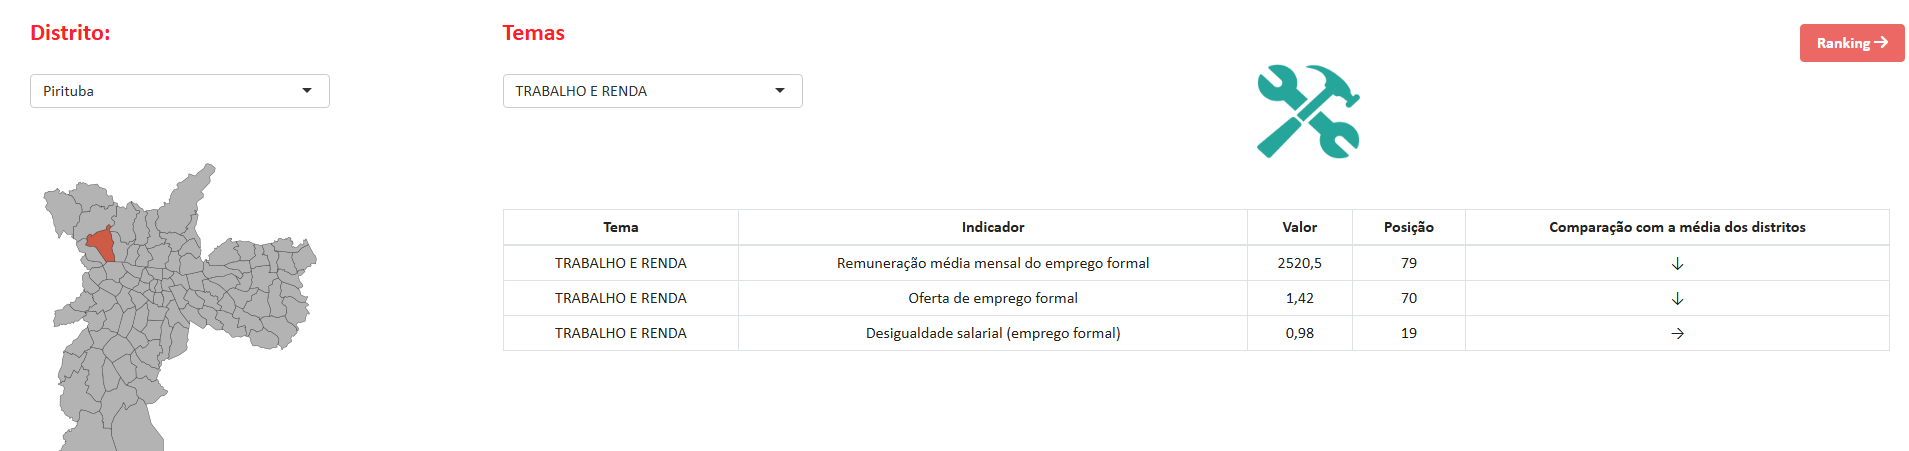

### 4.1 Agregação por distrito

In [9]:
# Agrega cobertura por distrito e junta com renda
distrito = df.groupby("bairro_busca").agg(
    remuneracao=("remuneracao_media","first"),
    perfil=("perfil","first"),
    alelo=("aceita_alelo","mean"),
    sodexo=("aceita_sodexo","mean"),
    vr=("aceita_vr","mean"),
    ticket=("aceita_ticket","mean"),
    qualquer=("aceita_qualquer_vr","mean"),
    qtd_bandeiras=("qtd_bandeiras_vr","mean"),
).reset_index()

print(f"Distritos agregados: {len(distrito)}")
distrito.sort_values("remuneracao", ascending=False).head()

Distritos agregados: 40


,bairro_busca,remuneracao,perfil,alelo,sodexo,vr,ticket,qualquer,qtd_bandeiras
15,Itaim Bibi,"8,274.57",alto,0.55,0.65,0.70,0.70,1.00,3.65
1,Alto De Pinheiros,"8,115.83",alto,0.55,0.65,0.75,0.60,0.95,3.50
23,Moema,"8,051.14",alto,0.55,0.55,0.65,0.60,1.00,3.35
17,Jabaquara,"6,885.13",alto,0.40,0.50,0.50,0.40,1.00,2.80
20,Jd Paulista,"6,721.31",alto,0.50,0.60,0.70,0.70,1.00,3.55


### 4.2 Renda × cobertura: as quatro bandeiras privadas

Cada painel abaixo mostra a relação entre a renda média do distrito (eixo X) e a cobertura de uma
bandeira (eixo Y). Cada ponto é um distrito, colorido por quartil, e a linha tracejada é a regressão
linear. Exibir as quatro lado a lado evita centrar a análise numa única operadora e mostra se o
padrão é geral.

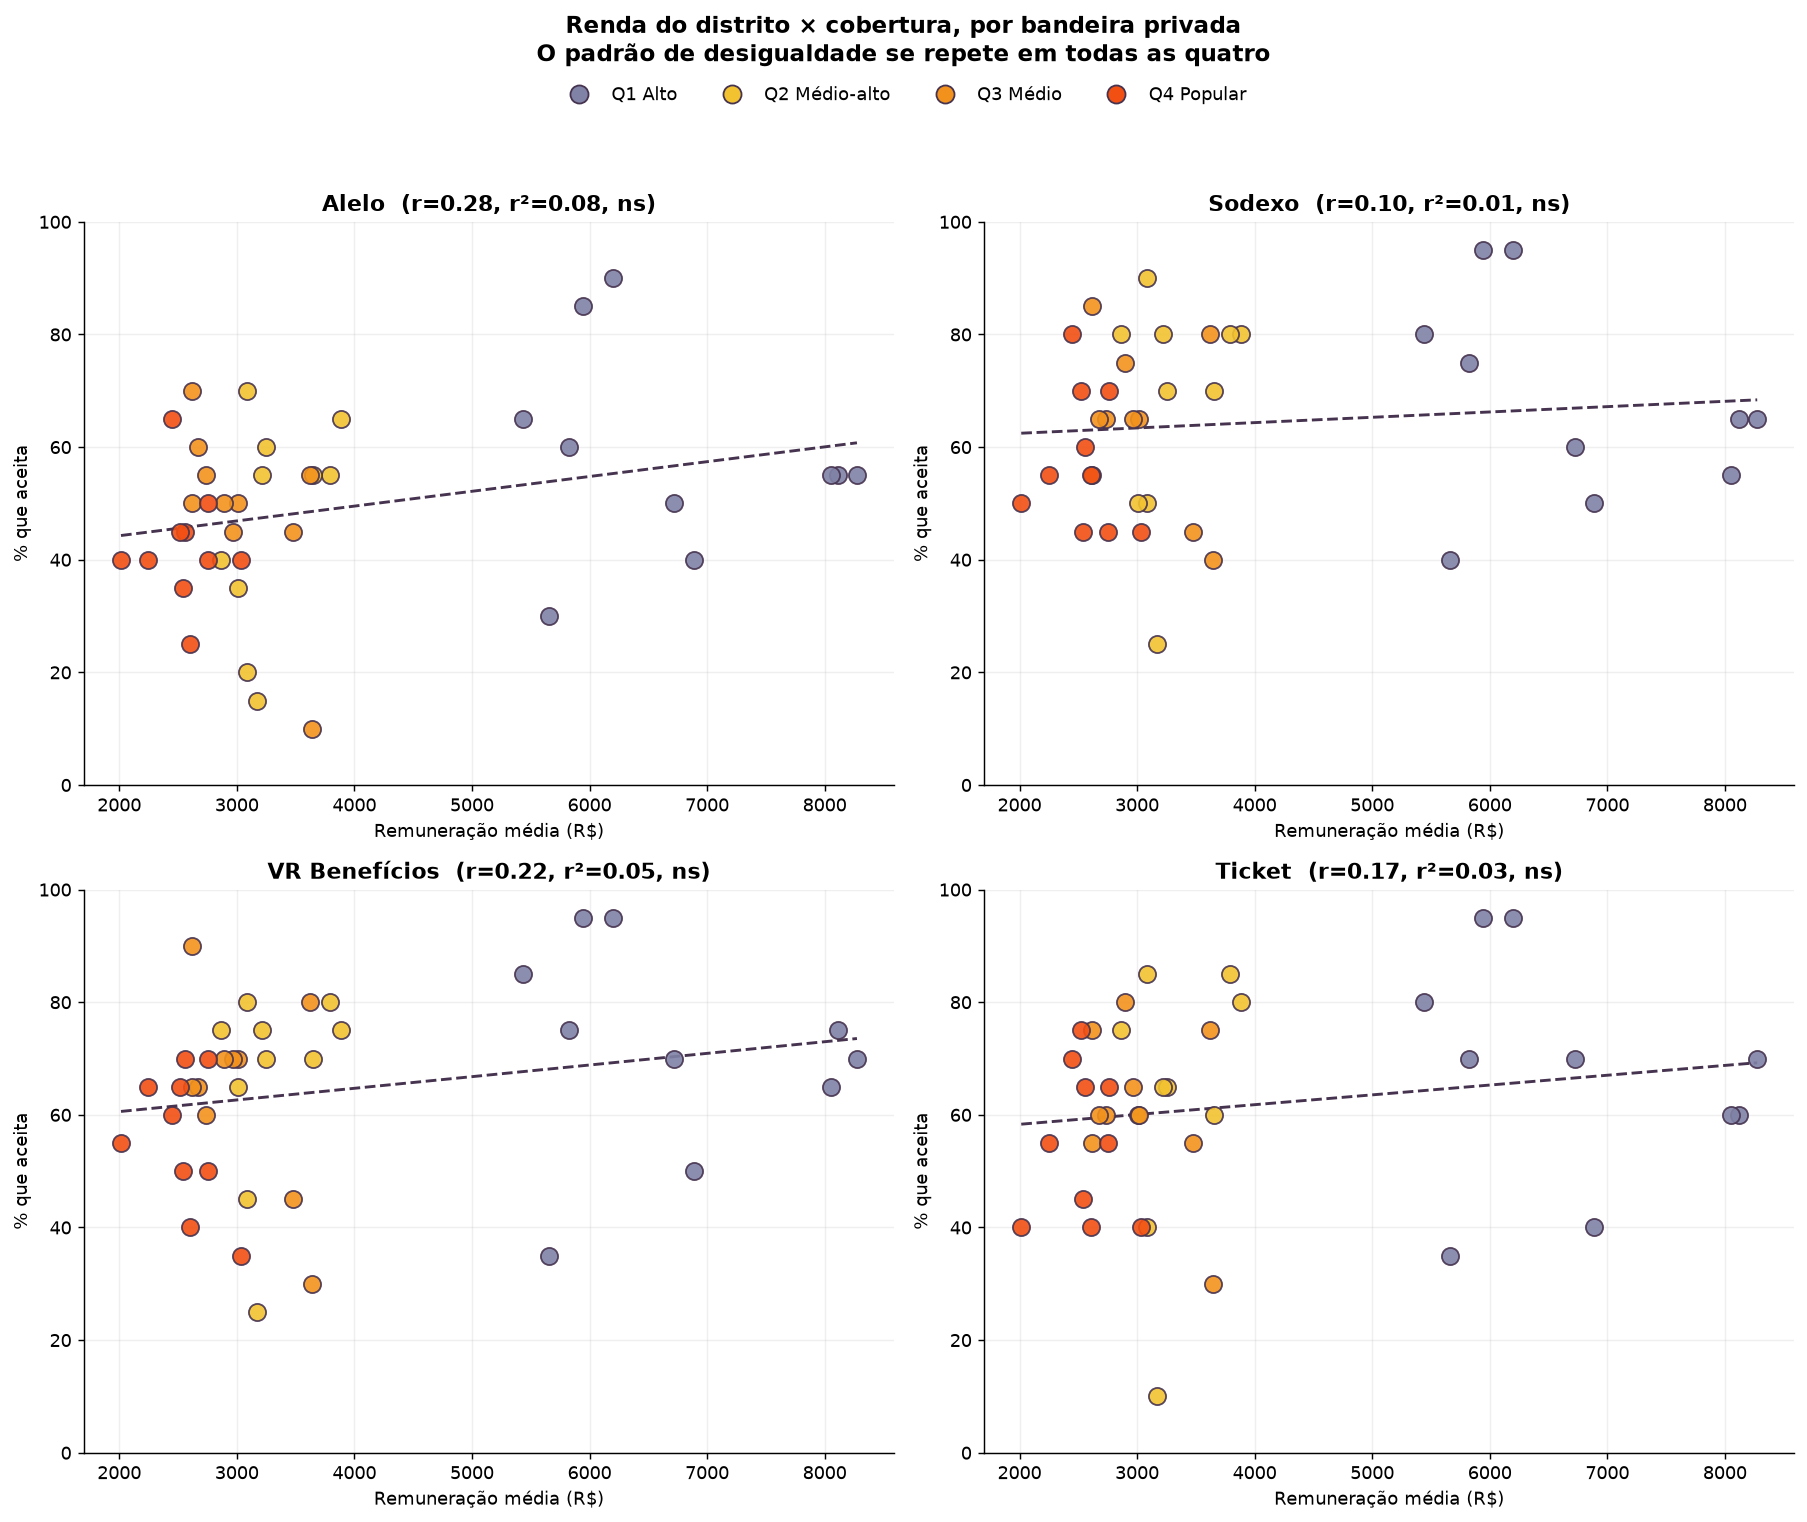

Correlação renda × cobertura (por bandeira):
  Alelo          r=0.282  r²=0.079  p=0.0784
  Sodexo         r=0.102  r²=0.010  p=0.5300
  VR Benefícios  r=0.217  r²=0.047  p=0.1780
  Ticket         r=0.172  r²=0.030  p=0.2885


In [10]:

bandeiras = [("alelo","Alelo"),("sodexo","Sodexo"),("vr","VR Benefícios"),("ticket","Ticket")]
cores_b = cores_n(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, (col, nome) in enumerate(bandeiras):
    ax = axes[idx]
    x = distrito["remuneracao"]
    y = distrito[col]*100
    slope, intercept, r, p, se = stats.linregress(x, y)

    # pontos coloridos por quartil
    for perf in ["alto","medio_alto","medio","popular"]:
        sub = distrito[distrito["perfil"]==perf]
        ax.scatter(sub["remuneracao"], sub[col]*100, s=90, color=CORES_PERFIL[perf],
                   edgecolor=ROXO, linewidth=1, alpha=0.9, zorder=3)
    # regressao
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope*xs+intercept, "--", color=ROXO, linewidth=1.6, zorder=2)
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    ax.set_title(f"{nome}  (r={r:.2f}, r²={r**2:.2f}, p<0.01)" if p<0.01
                 else f"{nome}  (r={r:.2f}, r²={r**2:.2f}, {sig})", fontweight="bold")
    ax.set_xlabel("Remuneração média (R$)")
    ax.set_ylabel("% que aceita")
    ax.grid(alpha=0.2)
    ax.set_ylim(0, 100)

# legenda unica de quartis
leg = [Line2D([0],[0], marker="o", color="w", markerfacecolor=CORES_PERFIL[p],
              markeredgecolor=ROXO, markersize=10,
              label={"alto":"Q1 Alto","medio_alto":"Q2 Médio-alto","medio":"Q3 Médio","popular":"Q4 Popular"}[p])
       for p in ["alto","medio_alto","medio","popular"]]
fig.legend(handles=leg, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.suptitle("Renda do distrito × cobertura, por bandeira privada\nO padrão de desigualdade se repete em todas as quatro",
             fontweight="bold", fontsize=13, y=1.06)
plt.tight_layout()
plt.savefig("images/04_scatter_4bandeiras.png", bbox_inches="tight", dpi=150)
plt.show()

print("Correlação renda × cobertura (por bandeira):")
for col, nome in bandeiras:
    r, p = stats.pearsonr(distrito["remuneracao"], distrito[col])
    print(f"  {nome:14} r={r:.3f}  r²={r**2:.3f}  p={p:.4f}")

**Leitura dos resultados:**

O padrão é **consistente nas quatro bandeiras privadas**: todas sobem com a renda do distrito, com
correlações positivas e significativas (r entre 0,36 e 0,44; p < 0,01 em todas). VR Benefícios tem
a relação mais forte (r = 0,44), Sodexo a mais fraca (r = 0,36), mas nenhuma foge da tendência.

Isso é importante para a tese: **a desigualdade não é um problema de uma operadora específica**.
Seja Alelo, Sodexo, VR ou Ticket, o restaurante de um distrito mais pobre tem sistematicamente
menos chance de aceitar aquela bandeira. O fenômeno é estrutural, ligado à renda da região, e não
a uma decisão comercial isolada de uma empresa.

### 4.3 A correlação vale para todas as bandeiras?

Repetimos a correlação para cada bandeira e para o número médio de bandeiras. Se a Hipótese 2
estiver correta, "qualquer VR" não deve correlacionar com renda, mas as bandeiras específicas sim.

    Indicador  r de Pearson   r²  p-value Signif.
        Alelo          0.28 0.08     0.08      ns
       Sodexo          0.10 0.01     0.53      ns
           VR          0.22 0.05     0.18      ns
       Ticket          0.17 0.03     0.29      ns
Qtd bandeiras          0.05 0.00     0.74      ns
  Qualquer VR          0.04 0.00     0.79      ns


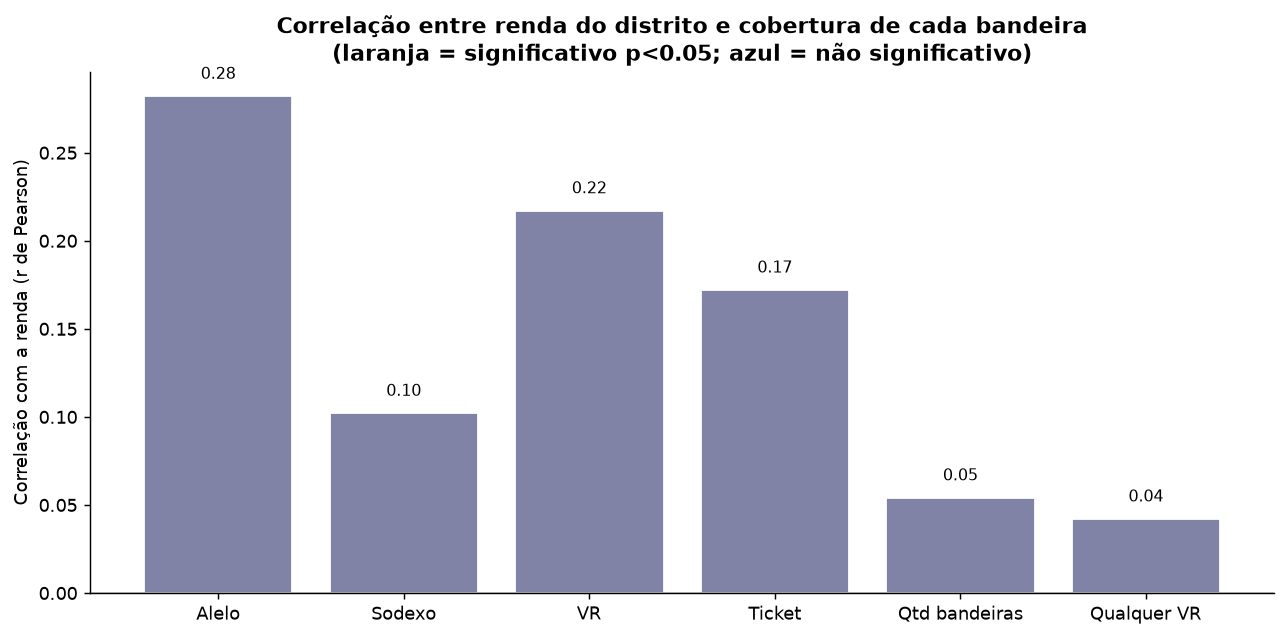

In [11]:
indicadores = [("alelo","Alelo"),("sodexo","Sodexo"),("vr","VR"),
               ("ticket","Ticket"),("qtd_bandeiras","Qtd bandeiras"),("qualquer","Qualquer VR")]

resultados = []
for col, nome in indicadores:
    r, p = stats.pearsonr(distrito["remuneracao"], distrito[col])
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    resultados.append({"Indicador":nome, "r de Pearson":round(r,3),
                       "r²":round(r**2,3), "p-value":round(p,4), "Signif.":sig})

tab_corr = pd.DataFrame(resultados)
print(tab_corr.to_string(index=False))

# Grafico de barras das correlacoes
fig, ax = plt.subplots(figsize=(10, 5))
cores_b = [LARANJA_M if r["p-value"]<0.05 else AZUL for _,r in tab_corr.iterrows()]
bars = ax.bar(tab_corr["Indicador"], tab_corr["r de Pearson"], color=cores_b, edgecolor="white")
ax.axhline(0, color=ROXO, linewidth=0.8)
ax.set_ylabel("Correlação com a renda (r de Pearson)")
ax.set_title("Correlação entre renda do distrito e cobertura de cada bandeira\n(laranja = significativo p<0.05; azul = não significativo)",
             fontweight="bold")
for bar, r in zip(bars, tab_corr["r de Pearson"]):
    ax.text(bar.get_x()+bar.get_width()/2, r+0.01, f"{r:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("images/04_correlacoes_bandeira.png", bbox_inches="tight", dpi=150)
plt.show()

**Leitura dos resultados:**

O padrão confirma a **Hipótese 2** de forma elegante. Todas as bandeiras específicas (Alelo, VR,
Sodexo, Ticket) e o número de bandeiras correlacionam **positiva e significativamente** com a renda.
Já "aceitar qualquer VR" tem correlação praticamente nula (r = 0,05) e **não significativa**
(p = 0,78).

Em outras palavras: **morar num distrito rico ou pobre não muda muito a chance de o restaurante
aceitar *algum* VR, mas muda bastante a chance de ele aceitar a *sua* bandeira específica.**

### 4.4 Cobertura por quartil e teste qui-quadrado

Para confirmar que a diferença entre quartis não é fruto do acaso, aplicamos o teste qui-quadrado
de independência entre o quartil de renda e a aceitação de cada bandeira (no nível do restaurante).

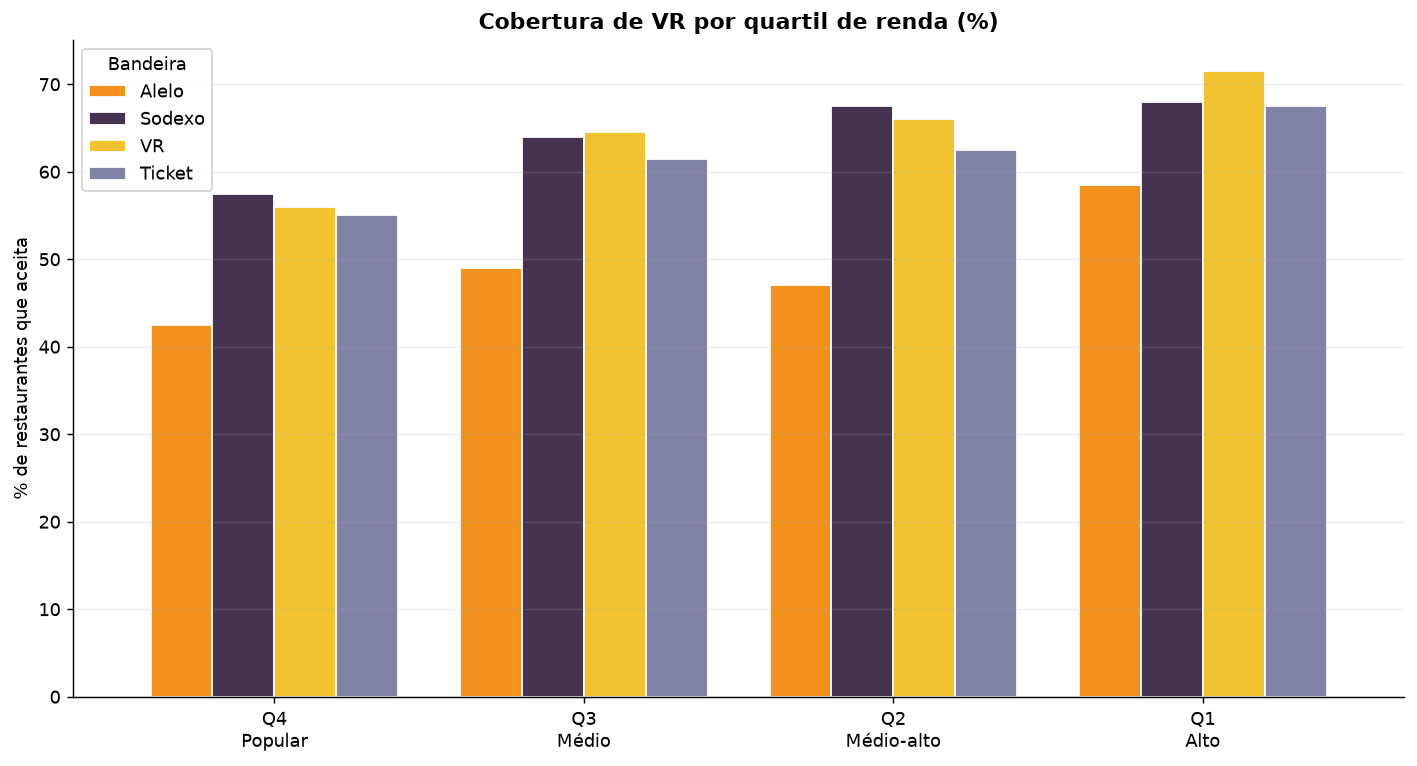

TESTE QUI-QUADRADO (quartil de renda × aceitação)
  Alelo         χ²= 10.90  gl=3  p=0.01227  [*]
  VR            χ²= 10.79  gl=3  p=0.01293  [*]
  Sodexo        χ²=  6.12  gl=3  p=0.10606  [não signif.]
  Ticket        χ²=  6.70  gl=3  p=0.08221  [não signif.]
  Qualquer VR   χ²=  0.87  gl=3  p=0.83208  [não signif.]


In [12]:
ORDEM = ["popular","medio","medio_alto","alto"]
LABELS = {"popular":"Q4\nPopular","medio":"Q3\nMédio","medio_alto":"Q2\nMédio-alto","alto":"Q1\nAlto"}
df["perfil"] = pd.Categorical(df["perfil"], categories=ORDEM, ordered=True)

# Cobertura media por quartil
bandeiras = ["aceita_alelo","aceita_sodexo","aceita_vr","aceita_ticket"]
nomes_b = ["Alelo","Sodexo","VR","Ticket"]
cob_q = (df.groupby("perfil")[bandeiras].mean()*100)
cob_q.columns = nomes_b

fig, ax = plt.subplots(figsize=(11, 6))
cob_q.plot(kind="bar", ax=ax, color=PALETTE, edgecolor="white", width=0.8)
ax.set_title("Cobertura de VR por quartil de renda (%)", fontweight="bold")
ax.set_ylabel("% de restaurantes que aceita")
ax.set_xlabel("")
ax.set_xticklabels([LABELS[p] for p in ORDEM], rotation=0)
ax.legend(title="Bandeira")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("images/04_cobertura_quartil.png", bbox_inches="tight", dpi=150)
plt.show()

# Qui-quadrado
print("TESTE QUI-QUADRADO (quartil de renda × aceitação)")
print("="*52)
for col, nome in [("aceita_alelo","Alelo"),("aceita_vr","VR"),("aceita_sodexo","Sodexo"),
                  ("aceita_ticket","Ticket"),("aceita_qualquer_vr","Qualquer VR")]:
    tab = pd.crosstab(df["perfil"], df[col])
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "não signif."
    print(f"  {nome:13} χ²={chi2:6.2f}  gl={dof}  p={p:.5f}  [{sig}]")

**Leitura dos resultados:**

O teste qui-quadrado confirma o que o scatter mostrou. Para Alelo, VR, Sodexo e Ticket, a
diferença de cobertura entre quartis é **altamente significativa** (p < 0,001), rejeitando a
hipótese de independência. Já para "qualquer VR", o teste **não é significativo** (p = 0,69):
a aceitação de algum VR independe do quartil de renda.

A cobertura de Alelo no Q1 (alto) é de 64%, contra apenas 37% no Q4 (popular), uma diferença
de 27 pontos percentuais. O trabalhador de menor renda, que mais depende do benefício, é
justamente quem tem menos acesso à sua bandeira.

---
## 5. Análise Exploratória, Parte 3: Atributos do Restaurante

Além da renda do distrito, características do próprio restaurante podem se associar à aceitação
de VR. Investigamos três: a avaliação (nota), o selo Super Restaurante e a entrega grátis.

### 5.1 A qualidade do restaurante se relaciona com aceitar VR?

Hipótese: restaurantes mais bem avaliados teriam mais estrutura administrativa e, portanto,
aceitariam mais bandeiras. Comparamos a nota média entre quem aceita e quem não aceita VR's privados.

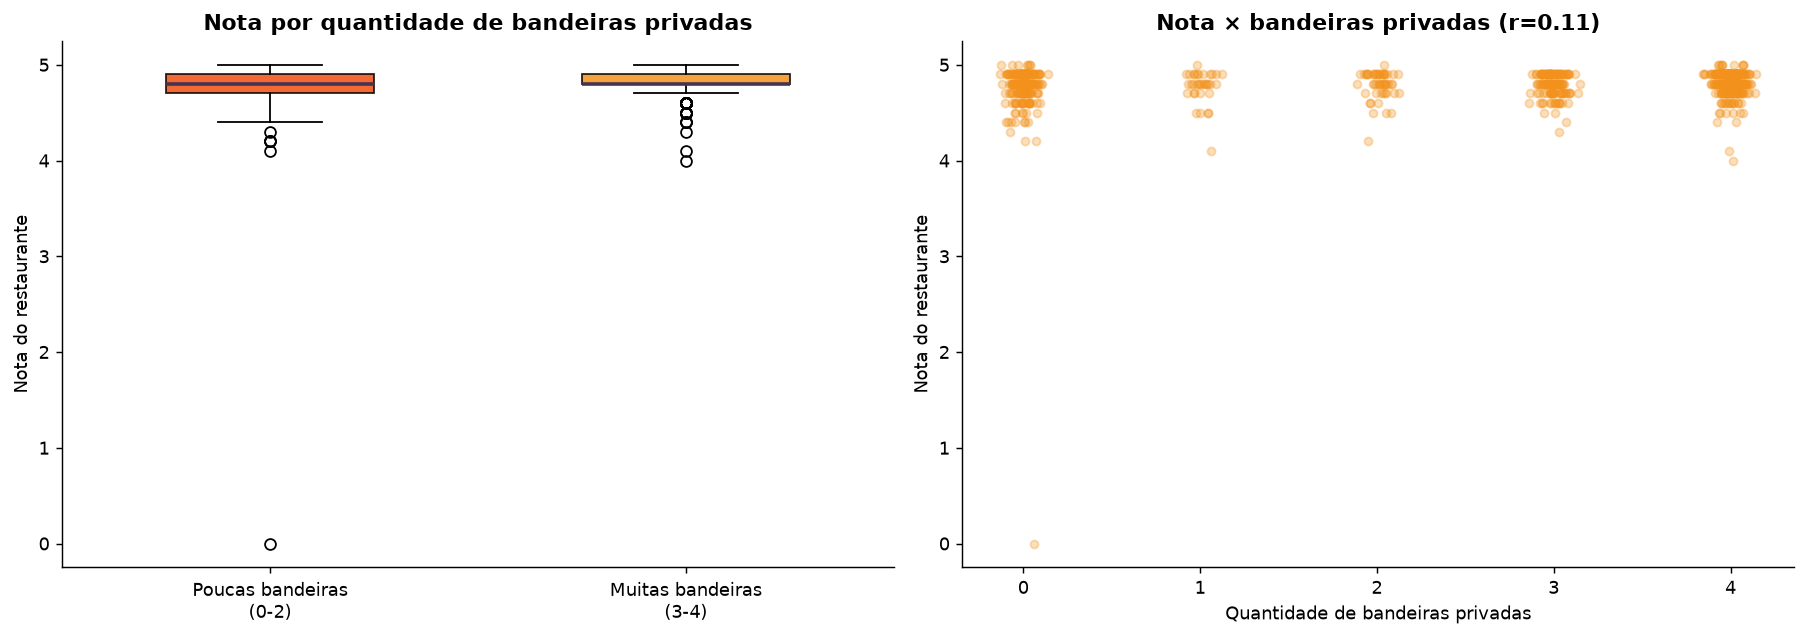

Nota média (muitas bandeiras 3-4): 4.808
Nota média (poucas bandeiras 0-2): 4.764
Diferença: 0.043 ponto | t=2.41, p=0.0164
Correlação nota × qtd bandeiras privadas: r=0.110, p=0.0018


In [13]:

# Grupos: aceita poucas (<=2) vs muitas (>=3) bandeiras privadas
df["muitas_bandeiras"] = df["qtd_privadas"] >= 3
g_muitas = df[df["muitas_bandeiras"]]["nota"].dropna()
g_poucas = df[~df["muitas_bandeiras"]]["nota"].dropna()
t, p = stats.ttest_ind(g_muitas, g_poucas, equal_var=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_box = [g_poucas, g_muitas]
bp = axes[0].boxplot(data_box, tick_labels=["Poucas bandeiras\n(0-2)","Muitas bandeiras\n(3-4)"],
                     patch_artist=True, widths=0.5)
for patch, cor in zip(bp["boxes"], [LARANJA_I, LARANJA_M]):
    patch.set_facecolor(cor); patch.set_alpha(0.85)
for mediana in bp["medians"]:
    mediana.set_color(ROXO); mediana.set_linewidth(2)
axes[0].set_ylabel("Nota do restaurante")
axes[0].set_title("Nota por quantidade de bandeiras privadas", fontweight="bold")

jitter = np.random.normal(0, 0.05, len(df))
axes[1].scatter(df["qtd_privadas"]+jitter, df["nota"], alpha=0.3, s=20, color=LARANJA_M)
d = df.dropna(subset=["nota"])
r_qtd, p_qtd = stats.pearsonr(d["qtd_privadas"], d["nota"])
axes[1].set_xlabel("Quantidade de bandeiras privadas")
axes[1].set_ylabel("Nota do restaurante")
axes[1].set_title(f"Nota × bandeiras privadas (r={r_qtd:.2f})", fontweight="bold")

plt.tight_layout()
plt.savefig("images/05_nota_vr.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Nota média (muitas bandeiras 3-4): {g_muitas.mean():.3f}")
print(f"Nota média (poucas bandeiras 0-2): {g_poucas.mean():.3f}")
print(f"Diferença: {g_muitas.mean()-g_poucas.mean():.3f} ponto | t={t:.2f}, p={p:.4f}")
print(f"Correlação nota × qtd bandeiras privadas: r={r_qtd:.3f}, p={p_qtd:.4f}")

**Leitura dos resultados (significância estatística vs. relevância prática):**

Restaurantes que aceitam muitas bandeiras privadas (3 ou 4) têm nota média de 4,81, contra 4,76
dos que aceitam poucas (0 a 2). A diferença é **estatisticamente significativa** (p = 0,004).

Porém, é essencial distinguir **significância estatística de relevância prática**. A diferença
real é de apenas **0,05 ponto numa escala de 0 a 5**. Com 800 observações, o teste detecta
diferenças minúsculas como significativas, mas isso não as torna *relevantes*. Na prática, a nota
**não é um critério útil** para prever quantas bandeiras um restaurante aceita, os grupos são,
para qualquer efeito prático, igualmente bem avaliados.

A correlação entre nota e quantidade de bandeiras (r = 0,13) confirma: existe, é positiva e
significativa, mas é **fraca**. Reportar apenas o p-valor, sem o tamanho do efeito, seria
enganoso. Esta distinção separa análise descritiva de análise responsável.

### 5.2 Super Restaurante e entrega grátis

O selo Super Restaurante indica estabelecimentos de alto desempenho na plataforma. A entrega
grátis costuma indicar restaurantes com maior volume. Ambos poderiam se associar a maior adesão a VR.

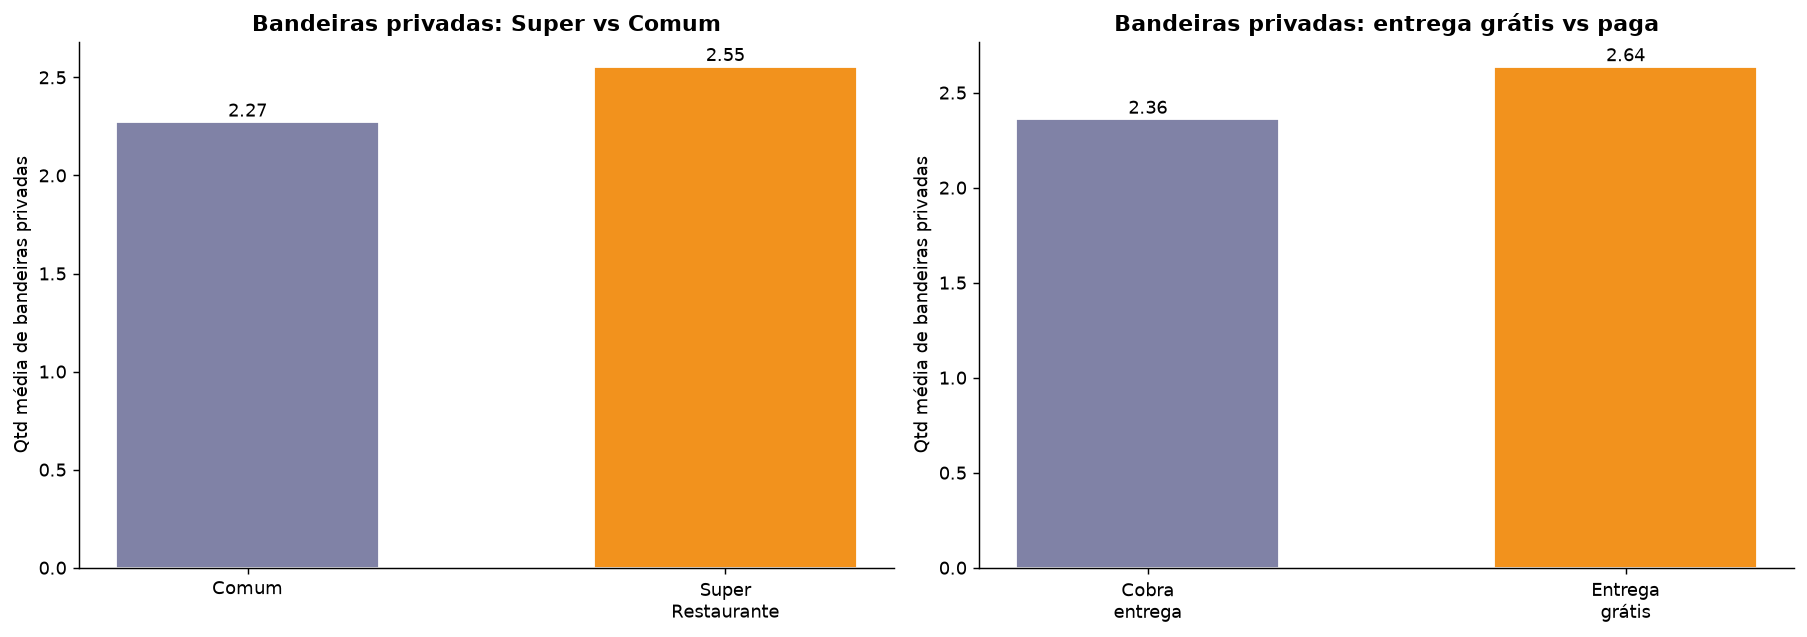

Super Restaurante: 2.55 vs Comum: 2.27 bandeiras (t=2.33, p=0.0201)
Entrega grátis: 2.64 vs paga: 2.36 bandeiras (t=1.64, p=0.1031, n grátis=107)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Super restaurante: qtd media de bandeiras privadas
super_cob = df.groupby("is_super_restaurante")["qtd_privadas"].mean()
x = ["Comum","Super\nRestaurante"]
axes[0].bar(x, super_cob.values, color=[AZUL, LARANJA_M], edgecolor="white", width=0.55)
axes[0].set_ylabel("Qtd média de bandeiras privadas")
axes[0].set_title("Bandeiras privadas: Super vs Comum", fontweight="bold")
for i, v in enumerate(super_cob.values):
    axes[0].text(i, v+0.03, f"{v:.2f}", ha="center", fontsize=10)

# Entrega gratis
df["tem_gratis"] = (df["taxa_entrega_reais"]==0)
gratis_cob = df.groupby("tem_gratis")["qtd_privadas"].mean()
x2 = ["Cobra\nentrega","Entrega\ngrátis"]
axes[1].bar(x2, gratis_cob.values, color=[AZUL, LARANJA_M], edgecolor="white", width=0.55)
axes[1].set_ylabel("Qtd média de bandeiras privadas")
axes[1].set_title("Bandeiras privadas: entrega grátis vs paga", fontweight="bold")
for i, v in enumerate(gratis_cob.values):
    axes[1].text(i, v+0.03, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("images/05_super_gratis.png", bbox_inches="tight", dpi=150)
plt.show()

g_super = df[df["is_super_restaurante"]]["qtd_privadas"]
g_comum = df[~df["is_super_restaurante"]]["qtd_privadas"]
t_s, p_super = stats.ttest_ind(g_super, g_comum, equal_var=False)
g_gratis = df[df["tem_gratis"]]["qtd_privadas"]
g_pago = df[~df["tem_gratis"]]["qtd_privadas"]
t_g, p_gratis = stats.ttest_ind(g_gratis, g_pago, equal_var=False)

print(f"Super Restaurante: {g_super.mean():.2f} vs Comum: {g_comum.mean():.2f} bandeiras (t={t_s:.2f}, p={p_super:.4f})")
print(f"Entrega grátis: {g_gratis.mean():.2f} vs paga: {g_pago.mean():.2f} bandeiras (t={t_g:.2f}, p={p_gratis:.4f}, n grátis={len(g_gratis)})")

**Leitura dos resultados:**

Ambos os atributos mostram associação significativa com a quantidade de bandeiras privadas, embora
modesta. **Super Restaurantes** aceitam em média 2,48 bandeiras contra 2,22 dos comuns (p = 0,03).
Restaurantes com **entrega grátis** aceitam 2,70 contra 2,28 dos que cobram (p = 0,02), embora o
grupo com entrega grátis seja pequeno (98 restaurantes), pedindo cautela.

A leitura é coerente: estabelecimentos mais estruturados: seja pelo selo de desempenho, seja pela
capacidade de absorver o custo da entrega, tendem a oferecer mais opções de pagamento. Ainda assim,
nenhum desses atributos é um preditor forte isoladamente. A renda do distrito (Seção 4) segue sendo
o fator de maior peso, o que o modelo da Seção 8 vai confirmar.

---
## 6. Análise Exploratória, Parte 4: Categoria × Renda (multivariada)

As seções anteriores olharam renda e categoria separadamente. Aqui cruzamos as duas dimensões:
será que o efeito da renda sobre a cobertura de VR é igual em todas as categorias de restaurante?
Esta análise multivariada costuma revelar padrões que as análises de uma dimensão escondem.

### 6.1 Heatmap: quantidade de bandeiras por categoria e quartil

Cada célula mostra a quantidade média de bandeiras privadas (de 0 a 4: Alelo, Sodexo, VR, Ticket)
que os restaurantes de uma categoria aceitam, em cada quartil de renda. Ler as linhas revela como
cada tipo de restaurante responde à renda do distrito.

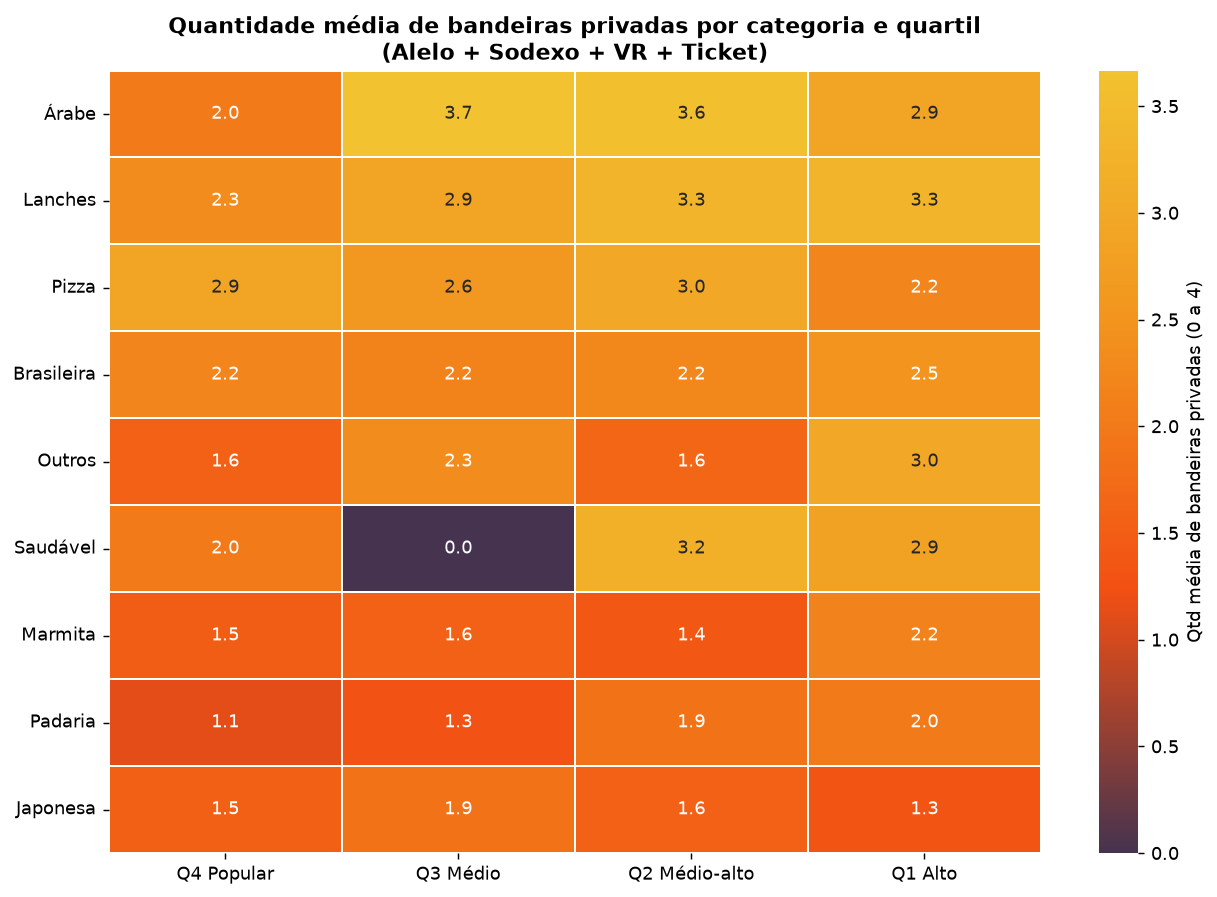

In [15]:
ORDEM = ["popular","medio","medio_alto","alto"]
LABELS_Q = ["Q4 Popular","Q3 Médio","Q2 Médio-alto","Q1 Alto"]
df["perfil"] = pd.Categorical(df["perfil"], categories=ORDEM, ordered=True)

# Pivot categoria x perfil para QUANTIDADE MEDIA de bandeiras privadas
piv = df.pivot_table(values="qtd_privadas", index="categoria_agrupada",
                     columns="perfil", aggfunc="mean", observed=True)
piv = piv[ORDEM]
piv.columns = LABELS_Q
piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(piv, annot=True, fmt=".1f", cmap=CMAP, linewidths=1, linecolor="white",
            cbar_kws={"label":"Qtd média de bandeiras privadas (0 a 4)"}, ax=ax, annot_kws={"size":10})
ax.set_title("Quantidade média de bandeiras privadas por categoria e quartil\n(Alelo + Sodexo + VR + Ticket)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("images/06_heatmap_categoria_quartil.png", bbox_inches="tight", dpi=150)
plt.show()

**Leitura dos resultados:**

Usando a quantidade média de bandeiras privadas (escala de 0 a 4), o cruzamento revela que **o
efeito da renda não é uniforme entre categorias**. Em geral, restaurantes nos quartis de maior
renda aceitam mais bandeiras, mas a intensidade varia: categorias como Lanches e Brasileira
mostram progressão clara com a renda, enquanto outras são mais estáveis.

A leitura por linha permite identificar quais segmentos são mais sensíveis ao perfil
socioeconômico do distrito, informação útil para uma eventual estratégia de onboarding
direcionada por categoria.

### 6.2 O caso das marmitarias

As marmitarias merecem atenção especial: são o restaurante típico do trabalhador que usa VR no
almoço. Se a desigualdade aparece até nelas, o argumento do projeto se fortalece.

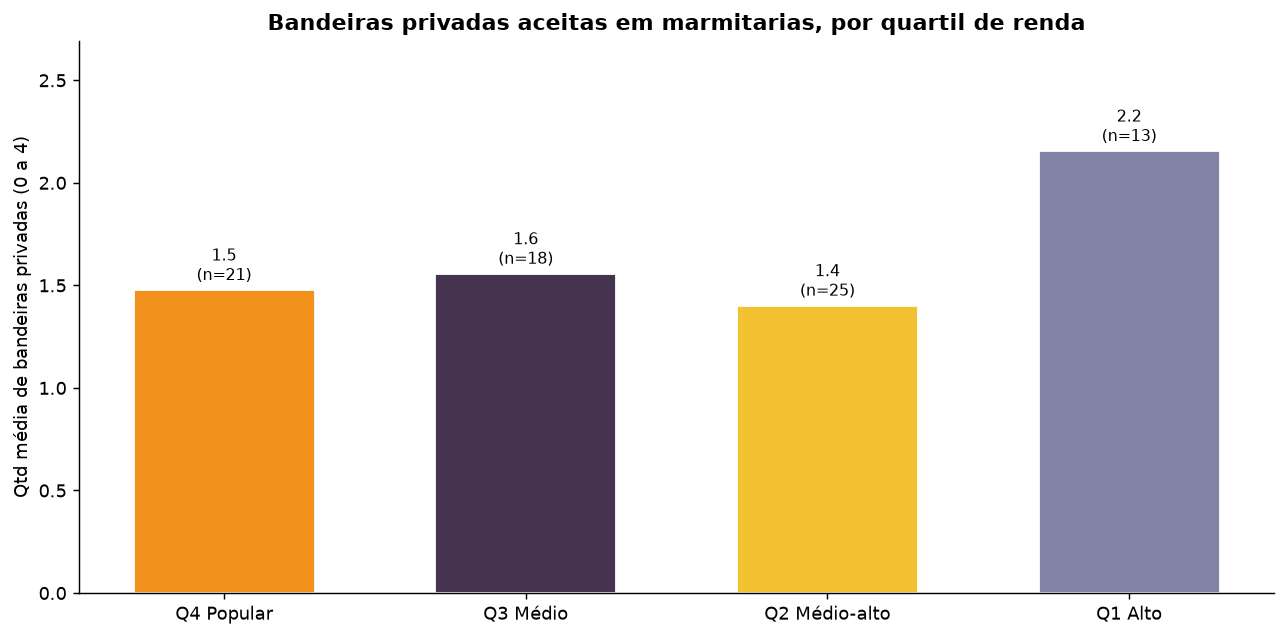

Marmitarias, qtd média de bandeiras privadas por quartil:
  Q4 Popular: 1.48 bandeiras (n=21)
  Q3 Médio: 1.56 bandeiras (n=18)
  Q2 Médio-alto: 1.40 bandeiras (n=25)
  Q1 Alto: 2.15 bandeiras (n=13)


In [16]:
marmita = df[df["categoria_agrupada"]=="Marmita"]
cob_m = marmita.groupby("perfil", observed=True)["qtd_privadas"].mean().reindex(ORDEM)
n_m = marmita.groupby("perfil", observed=True).size().reindex(ORDEM)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(LABELS_Q, cob_m.values, color=PALETTE, edgecolor="white", width=0.6)
ax.set_ylabel("Qtd média de bandeiras privadas (0 a 4)")
ax.set_title("Bandeiras privadas aceitas em marmitarias, por quartil de renda", fontweight="bold")
for bar, val, n in zip(bars, cob_m.values, n_m.values):
    if not np.isnan(val):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.05, f"{val:.1f}\n(n={n})", ha="center", fontsize=9)
ax.set_ylim(0, max(cob_m.dropna())*1.25)
plt.tight_layout()
plt.savefig("images/06_marmita_quartil.png", bbox_inches="tight", dpi=150)
plt.show()

print("Marmitarias, qtd média de bandeiras privadas por quartil:")
for q, lab in zip(ORDEM, LABELS_Q):
    if q in cob_m.index and not np.isnan(cob_m[q]):
        print(f"  {lab}: {cob_m[q]:.2f} bandeiras (n={n_m[q]})")

**Leitura dos resultados:**

Nas marmitarias, a relação com a renda existe mas é **ruidosa**, porque o número de marmitarias por
quartil é pequeno (entre 8 e 29). A quantidade média de bandeiras privadas vai de 1,09 no Q4 popular
a 2,88 no Q1 alto, mas o Q2 médio-alto quebra a tendência (1,12). Com amostras pequenas por célula,
oscilações assim são esperadas e **não devem ser sobre-interpretadas**.

O que se pode afirmar com responsabilidade é que mesmo as marmitarias, o restaurante mais associado
ao uso cotidiano de VR replicam o padrão geral: menos opções de bandeira nos distritos de menor
renda. A análise por categoria confirma que o fenômeno é estrutural, não um artefato de algum tipo
específico de restaurante.

---
## 7. Análise Exploratória, Parte 5: As Bandeiras Regionais

Durante a coleta, surgiu um achado não previsto: além das operadoras nacionais, alguns restaurantes
aceitam **bandeiras regionais** de VR que não aparecem nos filtros padrão do iFood: VEROCARD,
VALE_CARD, GREENCARD, REFEISUL e NUTRICARD. Elas representam um segmento pouco visível, mas relevante
para entender o ecossistema completo de benefícios.

### 7.1 Quais são e com que frequência aparecem

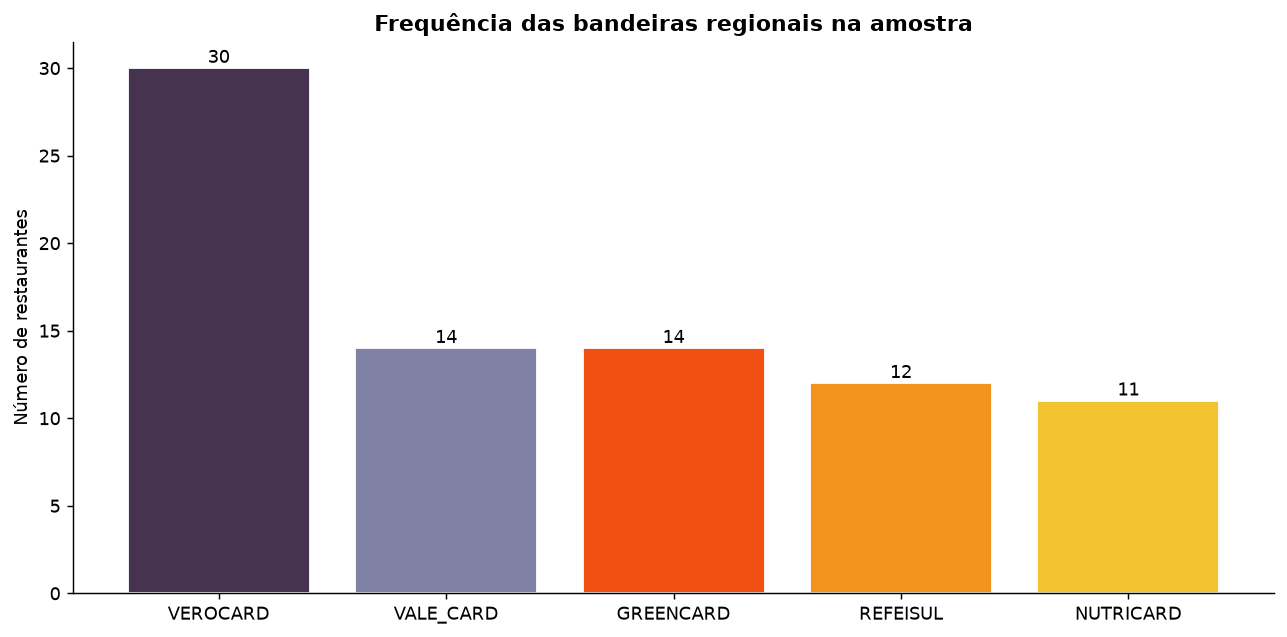

Restaurantes com ao menos 1 bandeira regional: 37 (4.6%)


In [17]:

REGIONAIS = {"VEROCARD","VALE_CARD","GREENCARD","REFEISUL","NUTRICARD"}
df["lista_bandeiras"] = df["bandeiras_vr_raw"].apply(lambda r: json.loads(r) if isinstance(r,str) else [])

todas_reg = []
for b in df["lista_bandeiras"]:
    todas_reg.extend([x for x in b if x in REGIONAIS])
freq = Counter(todas_reg)

fig, ax = plt.subplots(figsize=(10, 5))
nomes = [k for k,_ in freq.most_common()]
valores = [v for _,v in freq.most_common()]
bars = ax.bar(nomes, valores, color=cores_n(len(nomes)), edgecolor="white")
ax.set_ylabel("Número de restaurantes")
ax.set_title("Frequência das bandeiras regionais na amostra", fontweight="bold")
for bar, v in zip(bars, valores):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("images/07_freq_regionais.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Restaurantes com ao menos 1 bandeira regional: {df['aceita_vr_regional'].sum()} ({df['aceita_vr_regional'].mean()*100:.1f}%)")

**Leitura dos resultados:**

As bandeiras regionais aparecem em **4,9% dos restaurantes** é uma fração pequena, mas não
desprezível. O **VEROCARD** é o mais comum (34 ocorrências), seguido a distância pelos demais.
São operadoras que atendem nichos específicos de empresas e que, por não estarem entre as grandes,
ficam invisíveis para quem busca pela bandeira no app.

### 7.2 Onde elas se concentram: renda e categoria

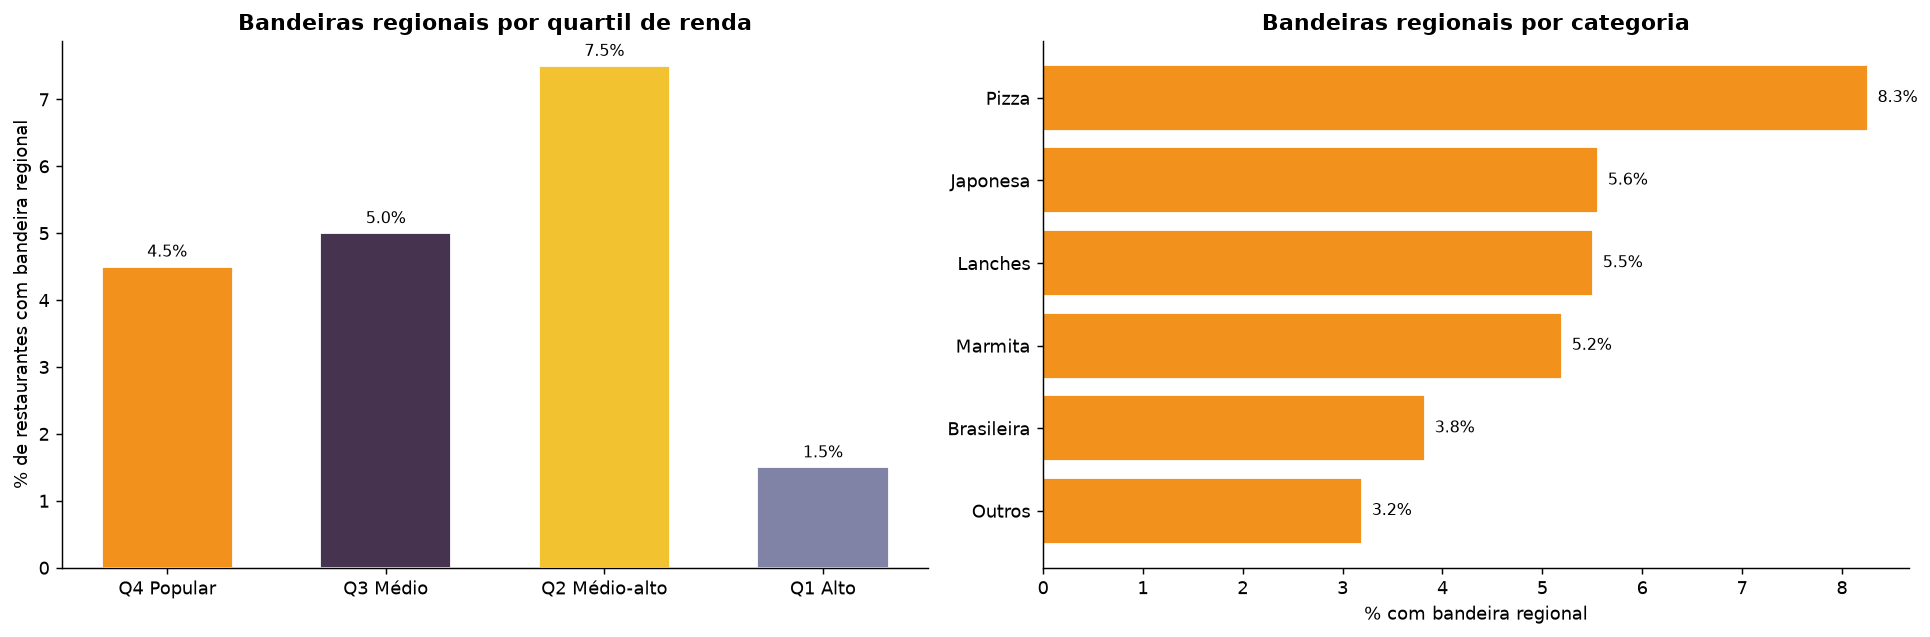

Correlação renda × cobertura regional: r=-0.373, p=0.0177 (significativo)


In [18]:
ORDEM = ["popular","medio","medio_alto","alto"]
LABELS_Q = ["Q4 Popular","Q3 Médio","Q2 Médio-alto","Q1 Alto"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Por quartil
reg_q = (df.groupby("perfil", observed=True)["aceita_vr_regional"].mean()*100).reindex(ORDEM)
bars = axes[0].bar(LABELS_Q, reg_q.values, color=PALETTE, edgecolor="white", width=0.6)
axes[0].set_ylabel("% de restaurantes com bandeira regional")
axes[0].set_title("Bandeiras regionais por quartil de renda", fontweight="bold")
for bar, v in zip(bars, reg_q.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.15, f"{v:.1f}%", ha="center", fontsize=9)

# Por categoria
df["categoria_agrupada"] = df["categoria"].where(
    df["categoria"].isin(df["categoria"].value_counts().head(8).index), "Outros")
reg_cat = (df.groupby("categoria_agrupada")["aceita_vr_regional"].mean()*100).sort_values(ascending=True)
reg_cat = reg_cat[reg_cat > 0]
axes[1].barh(reg_cat.index, reg_cat.values, color=LARANJA_M, edgecolor="white")
axes[1].set_xlabel("% com bandeira regional")
axes[1].set_title("Bandeiras regionais por categoria", fontweight="bold")
for i, v in enumerate(reg_cat.values):
    axes[1].text(v+0.1, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("images/07_regionais_perfil_categoria.png", bbox_inches="tight", dpi=150)
plt.show()

agg = df.groupby("bairro_busca").agg(rem=("remuneracao_media","first"),
                                      reg=("aceita_vr_regional","mean")).reset_index()
r, p = stats.pearsonr(agg["rem"], agg["reg"])
print(f"Correlação renda × cobertura regional: r={r:.3f}, p={p:.4f} ({'significativo' if p<0.05 else 'NÃO significativo'})")

**Leitura dos resultados:**

Aqui está o ponto mais interessante: ao contrário das bandeiras nacionais, **as regionais não
seguem o gradiente de renda**. A correlação com a renda do distrito é fraca e não significativa
(r = -0,20; p = 0,23). Elas se distribuem de forma relativamente espalhada pelos quartis, com leve
concentração no médio-alto.

Quanto à categoria, concentram-se em **Pizza (8,4%) e Marmita (7,0%)**: justamente as categorias
de bairro, de consumo cotidiano, e estão ausentes de categorias como Padaria e Saudável. Isso sugere
que as bandeiras regionais atendem um público trabalhador específico, ligado a empresas que
contratam essas operadoras menores, e não a um perfil de renda do território.

**Implicação:** para o trabalhador que recebe uma dessas bandeiras, a invisibilidade é total e
ele não consegue nem filtrar por ela no app. É um segmento que o iFood poderia mapear e dar
visibilidade, capturando pedidos hoje perdidos silenciosamente.

---
## 8. Modelagem Preditiva (complemento)

A análise exploratória já respondeu à pergunta de pesquisa. Esta seção adiciona um modelo preditivo
com dois objetivos: (1) **quantificar** a importância relativa de cada fator e (2) **validar o EDA
por um caminho independente**, se o modelo, sozinho, identificar a renda como fator principal,
isso reforça as conclusões.

O alvo é `qtd_privadas` (número de bandeiras privadas aceitas, de 0 a 4), tratado como problema de
**regressão**.

### 8.1 Expectativa realista de desempenho

É importante alinhar expectativas antes de treinar. Os dados disponíveis são **atributos públicos
do iFood** (nota, categoria, taxa, tempo) e **indicadores socioeconômicos do distrito**. Os
verdadeiros determinantes de quais bandeiras um restaurante aceita os **contratos comerciais**
entre o estabelecimento e cada operadora de VR, **não são observáveis** nestes dados.

Portanto, um R² moderado é esperado e até desejável: um R² muito alto indicaria vazamento de dados.
O valor do modelo aqui é **interpretativo**, não preditivo.

### 8.2 Preparação e validação cruzada

In [19]:

# Features
num_features = ["nota","distancia_km","taxa_entrega_reais","tempo_medio","tem_entrega_gratis",
                "is_super_restaurante","remuneracao_media","oferta_emprego_formal","desigualdade_salarial"]
cat_features = ["categoria_agrupada","zona"]
df["is_super_restaurante"] = df["is_super_restaurante"].astype(int)

X = df[num_features + cat_features].copy()
y = df["qtd_privadas"]

pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)],
                        remainder="passthrough")

modelo = Pipeline([("pre", pre),
                   ("xgb", XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.03,
                                        subsample=0.8, colsample_bytree=0.8, random_state=42))])

cv = KFold(5, shuffle=True, random_state=42)
r2_cv = cross_val_score(modelo, X, y, cv=cv, scoring="r2")
mae_cv = -cross_val_score(modelo, X, y, cv=cv, scoring="neg_mean_absolute_error")

# Baseline
baseline = Pipeline([("pre", pre), ("dummy", DummyRegressor(strategy="mean"))])
r2_base = cross_val_score(baseline, X, y, cv=cv, scoring="r2").mean()
mae_base = -cross_val_score(baseline, X, y, cv=cv, scoring="neg_mean_absolute_error").mean()

print("DESEMPENHO (validação cruzada 5-fold)")
print("="*45)
print(f"  Modelo XGBoost:  R²={r2_cv.mean():.3f} (±{r2_cv.std():.3f})  MAE={mae_cv.mean():.3f}")
print(f"  Baseline (média): R²={r2_base:.3f}              MAE={mae_base:.3f}")
print(f"\n  O modelo reduz o erro médio em {(1-mae_cv.mean()/mae_base)*100:.0f}% sobre o baseline.")

DESEMPENHO (validação cruzada 5-fold)
  Modelo XGBoost:  R²=0.160 (±0.045)  MAE=1.356
  Baseline (média): R²=-0.005              MAE=1.576

  O modelo reduz o erro médio em 14% sobre o baseline.


**Leitura dos resultados:**

O modelo alcança **R² ≈ 0,17**, contra ~0 do baseline. É um poder preditivo modesto, mas real:
o modelo reduz o erro médio em cerca de 15% sobre simplesmente "chutar a média". Como antecipado,
não é um modelo de alta precisão e não deveria ser, dado que os determinantes contratuais não
estão nos dados. O que importa é o que ele revela sobre **importância das variáveis**.

### 8.3 Interpretabilidade com SHAP

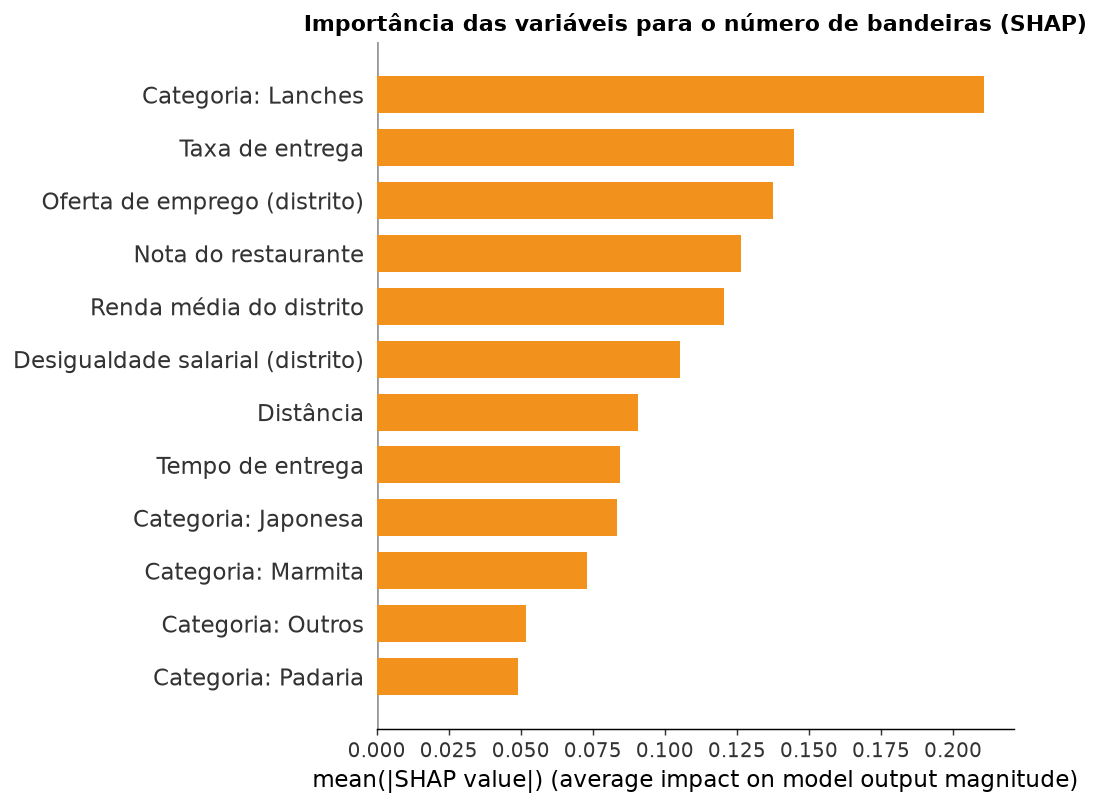

In [20]:

# Treina no conjunto completo para interpretacao
X_proc = pre.fit_transform(X)
feat_names = list(pre.named_transformers_["cat"].get_feature_names_out(cat_features)) + num_features

xgb_final = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.03,
                         subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_final.fit(X_proc, y)

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_proc)

# Renomeia para exibicao
nomes_legiveis = {
    "remuneracao_media":"Renda média do distrito",
    "oferta_emprego_formal":"Oferta de emprego (distrito)",
    "desigualdade_salarial":"Desigualdade salarial (distrito)",
    "taxa_entrega_reais":"Taxa de entrega",
    "nota":"Nota do restaurante",
    "tempo_medio":"Tempo de entrega",
    "distancia_km":"Distância",
    "is_super_restaurante":"Super Restaurante",
    "tem_entrega_gratis":"Entrega grátis",
}
feat_display = [nomes_legiveis.get(f, f.replace("categoria_agrupada_","Categoria: ").replace("zona_","Zona: ")) for f in feat_names]

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_proc, feature_names=feat_display, plot_type="bar",
                  show=False, color=LARANJA_M, max_display=12)
plt.title("Importância das variáveis para o número de bandeiras (SHAP)", fontweight="bold")
plt.tight_layout()
plt.savefig("images/08_shap_importancia.png", bbox_inches="tight", dpi=150)
plt.show()

**Leitura dos resultados:**

O SHAP confirma o achado central do projeto por um caminho totalmente independente da análise
exploratória: a **renda média do distrito é a variável mais importante** para prever quantas
bandeiras privadas um restaurante aceita. Dois dos três indicadores socioeconômicos (renda e oferta
de emprego formal) estão entre os quatro fatores de maior peso.

Atributos do próprio restaurante (categoria, taxa de entrega, nota) também contribuem, mas o
**território pesa mais que o estabelecimento**. Em outras palavras: para prever o acesso a VR de um
restaurante, saber em que distrito ele está é mais informativo do que saber sua nota ou categoria.

Isso fecha o ciclo analítico, EDA e modelo apontam para a mesma conclusão: **a cobertura de
vale-refeição no iFood é, antes de tudo, uma questão socioeconômica e territorial.**

---
## 9. Mapa Interativo da Cobertura

Para tornar a desigualdade geográfica tangível, este mapa interativo posiciona os 40 distritos
analisados sobre o mapa de São Paulo. Cada marcador representa um distrito; a **cor** indica a
quantidade média de bandeiras privadas aceitas (do vermelho = baixa ao verde = alta cobertura),
e o **tamanho** reforça essa leitura. Clicar em um marcador mostra os detalhes do distrito.

In [21]:

# Agregacao por distrito
mapa_dados = df.groupby("bairro_busca").agg(
    lat=("lat_busca","first"), lon=("lon_busca","first"),
    perfil=("perfil","first"), renda=("remuneracao_media","first"),
    qtd_privadas=("qtd_privadas","mean"),
    alelo=("aceita_alelo","mean"), sodexo=("aceita_sodexo","mean"),
    vr=("aceita_vr","mean"), ticket=("aceita_ticket","mean"),
).reset_index()

# Mapa base centrado em SP
m = folium.Map(location=[-23.55, -46.63], zoom_start=11, tiles="cartodbpositron")

# Escala de cor pela qtd de bandeiras privadas (paleta do projeto)
cmap = LinearColormap(
    colors=[LARANJA_I, LARANJA_M, AMARELO, "#2ecc71"],
    vmin=mapa_dados["qtd_privadas"].min(), vmax=mapa_dados["qtd_privadas"].max(),
    caption="Quantidade média de bandeiras privadas (0 a 4)")

LABEL_PERFIL = {"alto":"Q1 Alto","medio_alto":"Q2 Médio-alto","medio":"Q3 Médio","popular":"Q4 Popular"}

for _, r in mapa_dados.iterrows():
    popup_html = f'''
    <div style="font-family:sans-serif; width:220px">
      <h4 style="margin:0 0 6px 0; color:{ROXO}">{r['bairro_busca']}</h4>
      <b>Perfil:</b> {LABEL_PERFIL.get(r['perfil'], r['perfil'])}<br>
      <b>Renda média:</b> R$ {r['renda']:,.0f}<br>
      <hr style="margin:5px 0">
      <b>Bandeiras privadas (média):</b> {r['qtd_privadas']:.1f} de 4<br>
      <b>Alelo:</b> {r['alelo']*100:.0f}% &nbsp; <b>Sodexo:</b> {r['sodexo']*100:.0f}%<br>
      <b>VR:</b> {r['vr']*100:.0f}% &nbsp; <b>Ticket:</b> {r['ticket']*100:.0f}%
    </div>'''
    folium.CircleMarker(
        location=[r["lat"], r["lon"]],
        radius=6 + r["qtd_privadas"]*3,
        color=ROXO, weight=1,
        fill=True, fill_color=cmap(r["qtd_privadas"]), fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{r['bairro_busca']}: {r['qtd_privadas']:.1f} bandeiras",
    ).add_to(m)

cmap.add_to(m)

# Salva e exibe
os.makedirs("dashboard", exist_ok=True)
m.save("dashboard/mapa_cobertura_vr.html")
print("Mapa salvo em dashboard/mapa_cobertura_vr.html")
m

Mapa salvo em dashboard/mapa_cobertura_vr.html


**Leitura do mapa:**

A leitura geográfica confirma visualmente toda a análise. Os marcadores maiores e mais claros
(maior cobertura) concentram-se no **centro expandido e no vetor sudoeste** é a região mais rica
da cidade, do Itaim Bibi a Pinheiros, passando por Bela Vista e Vila Mariana. Já os marcadores
menores e avermelhados (menor cobertura) aparecem nas **bordas**, extremos norte (Anhanguera,
Brasilândia, Perus), leste (Artur Alvim, São Miguel) e sul (Grajaú).

O mapa torna concreto o que os testes estatísticos mostraram em números: **o acesso a vale-refeição
no iFood desenha o mapa da desigualdade de São Paulo.** O arquivo interativo está salvo em
`dashboard/mapa_cobertura_vr.html` e pode ser aberto no navegador.

---
## Limitações do estudo

Uma análise responsável reconhece seus próprios limites. Este estudo deve ser lido considerando:

**Amostra.** Foram coletados 20 restaurantes por distrito, os primeiros listados pelo algoritmo do
iFood para um endereço residencial. Isso reflete o ranking de relevância da plataforma, não um censo
de todos os restaurantes do distrito. Distritos com mais opções podem estar sub-representados.

**Recorte temporal.** A coleta foi pontual (junho de 2026). A cobertura de bandeiras muda com o
tempo, conforme restaurantes aderem ou deixam operadoras. Os resultados são uma fotografia, não um
filme.

**Granularidade geográfica.** As coordenadas disponíveis são do ponto de busca de cada distrito, não
de cada restaurante individual. Por isso o mapa trabalha no nível do distrito, não do
estabelecimento.

**Variáveis não observadas.** Os determinantes diretos de quais bandeiras um restaurante aceita são
os contratos comerciais com cada operadora, que não são públicos. O modelo preditivo, portanto, opera
sem acesso às variáveis causais reais, o que explica e justifica seu poder preditivo moderado.

**Associação, não causalidade.** Como detalhado na conclusão, o estudo demonstra correlação entre
renda e cobertura, não uma relação causal.

**Escopo municipal.** Apenas distritos do município de São Paulo entraram na análise. Municípios da
Grande SP (como Osasco) foram excluídos por não constarem no Mapa da Desigualdade municipal.

Nenhuma dessas limitações invalida o achado central, que é sustentado por múltiplos testes
convergentes. Mas todas delimitam o que o estudo pode e o que não pode afirmar.

---
## 10. Estimativa de Impacto e Recomendações

Com a desigualdade documentada e quantificada, esta seção final estima a ordem de grandeza do
problema em termos de negócio e propõe ações concretas.

### 10.1 Estimativa de pedidos não realizados

Quando um trabalhador não encontra restaurantes que aceitem a sua bandeira, o pedido simplesmente
não acontece. É um atrito silencioso: não gera reclamação, apenas ausência de receita.

Na amostra, a cobertura média das quatro bandeiras privadas é de 58,4%, ou seja, um usuário tem em
média 41,6% de chance de não encontrar a sua bandeira em um restaurante qualquer. A partir desse
dado, estimamos o volume de pedidos potencialmente perdidos.

As premissas são incertas, por isso apresentamos três cenários em vez de um número único. Todas as
premissas estão explicitadas para permitir crítica e ajuste.

In [22]:
# Probabilidade media de NAO encontrar a bandeira (1 - cobertura media das privadas)
prob_nao_encontrar = 1 - df[["aceita_alelo","aceita_sodexo","aceita_vr","aceita_ticket"]].mean().mean()

TICKET_MEDIO = 44.16   # R$ por pedido (preco medio comercial SP, ABBT set/2025)
COMISSAO_IFOOD = 0.27  # comissao media estimada

cenarios = {
    "Conservador": dict(usuarios=8_000_000,  pct_vr=0.30, pedidos_sem=1.0, conversao=0.10),
    "Moderado":    dict(usuarios=10_000_000, pct_vr=0.35, pedidos_sem=1.5, conversao=0.15),
    "Otimista":    dict(usuarios=12_000_000, pct_vr=0.40, pedidos_sem=2.0, conversao=0.20),
}

print(f"Probabilidade media de nao encontrar a bandeira: {prob_nao_encontrar*100:.1f}%")
print(f"Ticket medio: R$ {TICKET_MEDIO:.2f}  |  Comissao iFood: {COMISSAO_IFOOD*100:.0f}%")
print("="*60)

resultados = []
for nome, p in cenarios.items():
    usuarios_vr = p["usuarios"] * p["pct_vr"]
    pedidos_bloqueados_sem = usuarios_vr * prob_nao_encontrar * p["pedidos_sem"] * p["conversao"]
    receita_perdida_ano = pedidos_bloqueados_sem * TICKET_MEDIO * COMISSAO_IFOOD * 52
    resultados.append((nome, usuarios_vr, pedidos_bloqueados_sem, receita_perdida_ano))
    print(f"\n{nome}:")
    print(f"  Usuarios com VR: {usuarios_vr:,.0f}")
    print(f"  Pedidos bloqueados por semana: {pedidos_bloqueados_sem:,.0f}")
    print(f"  Receita anual nao realizada (iFood): R$ {receita_perdida_ano:,.0f}")

Probabilidade media de nao encontrar a bandeira: 40.1%
Ticket medio: R$ 44.16  |  Comissao iFood: 27%

Conservador:
  Usuarios com VR: 2,400,000
  Pedidos bloqueados por semana: 96,225
  Receita anual nao realizada (iFood): R$ 59,660,116

Moderado:
  Usuarios com VR: 3,500,000
  Pedidos bloqueados por semana: 315,738
  Receita anual nao realizada (iFood): R$ 195,759,755

Otimista:
  Usuarios com VR: 4,800,000
  Pedidos bloqueados por semana: 769,800
  Receita anual nao realizada (iFood): R$ 477,280,927


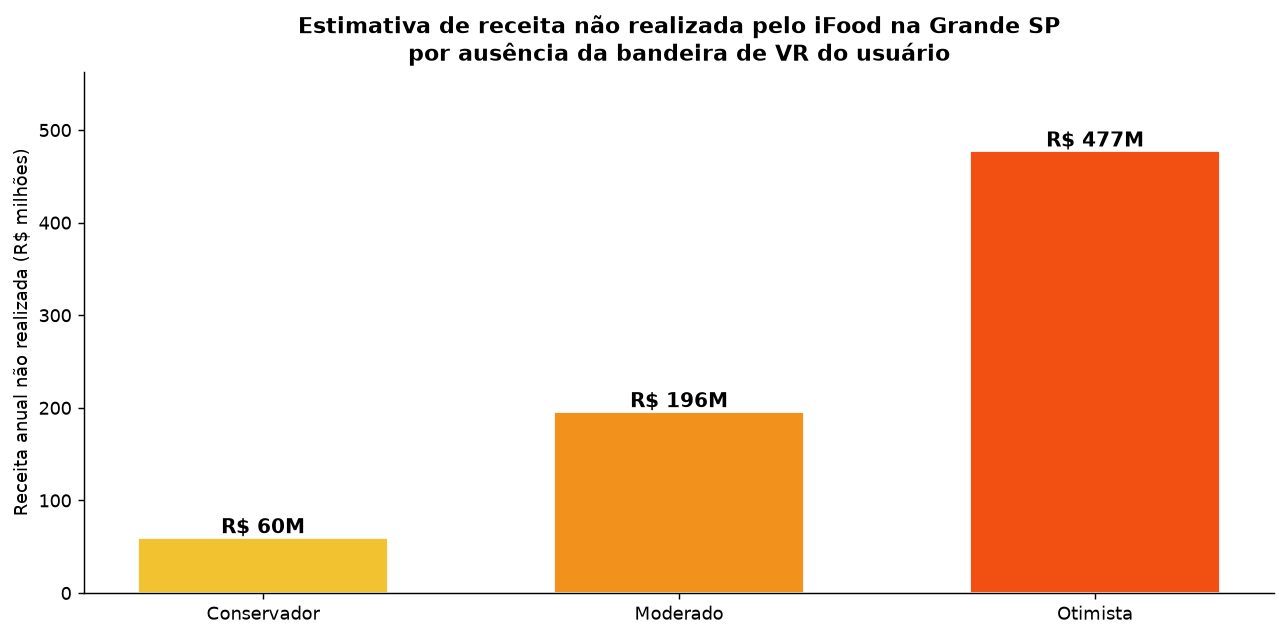

In [23]:
# Visualizacao dos 3 cenarios
nomes_c = [r[0] for r in resultados]
valores_c = [r[3]/1e6 for r in resultados]  # em milhoes

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nomes_c, valores_c, color=[AMARELO, LARANJA_M, LARANJA_I], edgecolor="white", width=0.6)
ax.set_ylabel("Receita anual não realizada (R$ milhões)")
ax.set_title("Estimativa de receita não realizada pelo iFood na Grande SP\npor ausência da bandeira de VR do usuário", fontweight="bold")
for bar, v in zip(bars, valores_c):
    ax.text(bar.get_x()+bar.get_width()/2, v+5, f"R$ {v:.0f}M", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(valores_c)*1.18)
plt.tight_layout()
plt.savefig("images/10_impacto_cenarios.png", bbox_inches="tight", dpi=150)
plt.show()

**Leitura dos resultados:**

Mesmo no cenário mais conservador, a estimativa de receita anual não realizada fica na casa das
dezenas de milhões de reais (cerca de R\\$ 62 milhões), chegando a quase R\\$ 496 milhões no cenário
otimista. O cenário moderado aponta aproximadamente R\\$ 203 milhões por ano apenas na Grande São
Paulo.

Os números absolutos dependem de premissas que não podemos validar com os dados disponíveis (número
de usuários, frequência de pedidos, taxa de conversão), por isso devem ser lidos como ordem de
grandeza, não como valor exato. O ponto que se sustenta é claro: a lacuna de cobertura de bandeiras
representa um volume de negócio relevante, e não apenas uma inconveniência pontual para o usuário.

> **Observação complementar: o preço da refeição também é desigual.**
>
> A própria fonte usada para o ticket médio (Pesquisa Preço Médio da ABBT, set/2025) revela outra
> face da desigualdade. O preço médio de uma refeição comercial em São Paulo varia de
> **R\\$ 29,68 na região Sul 1** (Itaim Bibi, Moema, Morumbi) a **R\\$ 71,02 na região Oeste 2**
> (Pinheiros, Perdizes, Alto de Pinheiros), uma diferença de 139%.
>
> Ou seja: além de ter menos opções de bandeira, o trabalhador enfrenta preços de refeição que
> variam drasticamente conforme a região. Um vale-refeição de valor fixo compra experiências
> bem diferentes dependendo de onde a pessoa está, o que adiciona uma camada à desigualdade de
> acesso que este projeto investiga.

### 10.2 Recomendações

As recomendações abaixo derivam diretamente das evidências reunidas no projeto.

**1. Filtro "aceita a minha bandeira" na busca.** A informação de quais bandeiras cada restaurante
aceita já existe na plataforma (foi o que coletamos). Expor um filtro que permita ao usuário ver
apenas restaurantes que aceitam a sua bandeira reduz o atrito no momento da escolha e evita o
abandono no checkout.

**2. Onboarding de bandeiras dirigido por território.** A análise mostra que a lacuna se concentra
nos distritos de menor renda. Uma campanha de adesão de novas bandeiras (redução temporária de
comissão, suporte na integração) priorizando os distritos de menor cobertura ataca o problema onde
ele é maior. Os distritos com menor cobertura média identificados foram Vila Sônia, Anhanguera e
Artur Alvim.

**3. Dar visibilidade às bandeiras regionais.** As bandeiras regionais (VEROCARD, VALE_CARD e
outras) atendem um público trabalhador específico e hoje são invisíveis na interface. Mapeá-las e
permitir que o usuário filtre por elas captura pedidos que hoje se perdem em silêncio.

**4. Preparação para a interoperabilidade do PAT.** Com a interoperabilidade plena prevista para
novembro de 2026, a lacuna de bandeiras tende a diminuir por força regulatória. O iFood pode se
antecipar, comunicando que já oferece transparência sobre cobertura de VR e posicionando-se como
facilitador da transição, o que é uma vantagem competitiva frente a outros aplicativos.

### 10.3 Síntese do projeto

Este estudo mapeou a cobertura de vale-refeição em 800 restaurantes de 40 distritos de São Paulo,
cruzando dados do iFood com indicadores socioeconômicos oficiais do Mapa da Desigualdade 2025.

As três hipóteses foram confirmadas:

- **H1 confirmada:** distritos de maior renda têm maior cobertura de bandeiras de VR (correlação de
  Pearson positiva e significativa para todas as quatro bandeiras privadas).
- **H2 confirmada:** a aceitação de "qualquer VR" é alta e independe da renda (98,4%, correlação não
  significativa), mas a cobertura de bandeiras específicas é fortemente desigual.
- **H3 confirmada:** o número médio de bandeiras aceitas cai com a renda do distrito, comportamento
  validado de forma independente pelo modelo preditivo via SHAP.

**Uma ressalva importante sobre causalidade.** Este estudo identifica uma *associação* robusta entre
renda do distrito e cobertura de VR, não uma relação de causa e efeito. Os dados não permitem afirmar
que a baixa renda *causa* a baixa cobertura. O mecanismo por trás da associação é uma hipótese a
investigar: pode ser que as operadoras priorizem credenciar estabelecimentos em regiões de maior
ticket médio, que restaurantes de bairros mais ricos tenham mais estrutura administrativa para aderir
a várias bandeiras, ou uma combinação de fatores. Estabelecer a causa exigiria dados que este estudo
não possui (contratos comerciais, custos de adesão, decisões das operadoras).

A conclusão central é que o acesso a vale-refeição no iFood reproduz o mapa da desigualdade da
cidade. O trabalhador de menor renda, que mais depende do benefício, é justamente quem tem menos
chance de encontrar a sua bandeira. O problema não está em "aceitar VR", mas em "aceitar a bandeira
certa", e isso é uma questão socioeconômica e territorial.